In [2]:
import numpy as np
from scipy.io import readsav
from datetime import datetime, timedelta
import scipy.integrate as integrate
from scipy.integrate import simpson as simp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.dates as mdates
import pdb
from scipy.io import loadmat  # but fname_sou = 'alphacen_all_visits.mat'
from scipy.io import savemat, loadmat


In [3]:

#----------------------------
def calculate_time_difference(start_time, end_time):
    """Calculates the time difference between two datetime objects."""

    time_difference = end_time - start_time

    days = time_difference.days
    hours, remainder = divmod(time_difference.seconds, 3600)
    minutes, seconds = divmod(remainder, 60)

    return days, hours, minutes, seconds
#--------------------------------
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth

In [5]:
from scipy.io import readsav
import numpy as np

#---------------------------MAIN PROGRAM-------------------
# Restore the CUTE Alpha Centauri spectra from the .sav files

fname_prof = '/Users/soumit/Downloads/Astronomy/Alpha_Cen/CUTE_visit45678_reduced_v3.sav'
fname_sou  = '/Users/soumit/Downloads/Astronomy/Alpha_Cen/version.sav'

# Load both files with readsav
sav_data_prof = readsav(fname_prof)
sav_data      = loadmat(fname_sou)

# wavelength solution from professor’s file
cute_wavesol = sav_data_prof['wave_sol']
mxw = cute_wavesol.max()
mnw = cute_wavesol.min()

# Your fluxes (from your sav file)
cute_ff4 = np.array(sav_data['flux_units_star4'])
cute_ff5 = np.array(sav_data['flux_units_star5'])
cute_ff6 = np.array(sav_data['flux_units_star6'])
cute_ff7 = np.array(sav_data['flux_units_star7'])
cute_ff8 = np.array(sav_data['flux_units_star8'])

# Backgrounds and raw spectra (renaming your sigdn/sigup usage)
cute_ff4_sigup = sav_data['spectrum4'] 
cute_ff4_sigdn = sav_data['background4']
cute_ff5_sigup = sav_data['spectrum5'] 
cute_ff5_sigdn = sav_data['background5']
cute_ff6_sigup = sav_data['spectrum6'] 
cute_ff6_sigdn = sav_data['background6']
cute_ff7_sigup = sav_data['spectrum7'] 
cute_ff7_sigdn = sav_data['background7']
cute_ff8_sigup = sav_data['spectrum8'] 
cute_ff8_sigdn = sav_data['background8']


# Number of exposures in each visit
nfiles4 = np.shape(cute_ff4)[1]
nfiles5 = np.shape(cute_ff5)[1]
nfiles6 = np.shape(cute_ff6)[1]
nfiles7 = np.shape(cute_ff7)[1]
nfiles8 = np.shape(cute_ff8)[1]

nfiles4        = np.shape(cute_ff4)[1]
nfiles5        = np.shape(cute_ff5)[1]
nfiles6        = np.shape(cute_ff6)[1]
nfiles7        = np.shape(cute_ff7)[1]

nfiles8        = np.shape(cute_ff8)[1]
dt_arr4        = sav_data_prof['date_obs4']
dt_arr5        = sav_data_prof['date_obs5']
dt_arr6        = sav_data_prof['date_obs6']
dt_arr7        = sav_data_prof['date_obs7']
dt_arr8        = sav_data_prof['date_obs8']
timearr4       = np.zeros(shape=nfiles4,dtype=float)
timearr5       = np.zeros(shape=nfiles5,dtype=float)
timearr6       = np.zeros(shape=nfiles6,dtype=float)
timearr7       = np.zeros(shape=nfiles7,dtype=float)
timearr8       = np.zeros(shape=nfiles8,dtype=float)
orbit_time4    = []
orbit_time5    = []
orbit_time6    = []
orbit_time7    = []
orbit_time8    = []
dates8         = []
dates7         = []
dates6         = []
dates5         = []
dates4         = []
dt4str         = []
dt5str         = []
dt6str         = []
dt7str         = []
dt8str         = []
# Time arrays (from professor’s sav, since your file doesn’t have dates)
# dt_arr4 = sav_data_prof['date_obs4']
# dt_arr5 = sav_data_prof['date_obs5']
# dt_arr6 = sav_data_prof['date_obs6']
# dt_arr7 = sav_data_prof['date_obs7']
# dt_arr8 = sav_data_prof['date_obs8']

# timearr4 = np.zeros(shape=nfiles4, dtype=float)
# timearr5 = np.zeros(shape=nfiles5, dtype=float)
# timearr6 = np.zeros(shape=nfiles6, dtype=float)
# timearr7 = np.zeros(shape=nfiles7, dtype=float)
# timearr8 = np.zeros(shape=nfiles8, dtype=float)

# orbit_time4, orbit_time5, orbit_time6, orbit_time7, orbit_time8 = [], [], [], [], []
# dates4, dates5, dates6, dates7, dates8 = [], [], [], [], []
# dt4str, dt5str, dt6str, dt7str, dt8str = [], [], [], [], []




In [6]:
#Getting the observation dates sorted out for all the visits
for i in range(nfiles4):
    st = dt_arr4[i]
    yr = int(st[0:4])
    mm = int(st[5:7])
    dd = int(st[8:10])
    hr = int(st[11:13])
    mn = int(st[14:16])
    ss = int(st[17:19])
    if (i == 0):
        startval = datetime(yr,mm,dd,hr,mn,ss)
    endval = datetime(yr,mm,dd,hr,mn,ss)
    days,hours,minutes,seconds = calculate_time_difference(startval,endval)
    time_diff   = days*24.*60*60. + hours*60.*60. + minutes*60. + seconds
    timearr4[i] = time_diff
    ddval       = datetime(yr,mm,dd,hr,mn,ss)
    dates4      = np.append(dates4,ddval)
    ddval2      = ddval.strftime("%Y-%m-%d %H:%M")
    dt4str      = np.append(dt4str,ddval2)
 
for i in range(nfiles5):
    st = dt_arr5[i]
    yr = int(st[0:4])
    mm = int(st[5:7])
    dd = int(st[8:10])
    hr = int(st[11:13])
    mn = int(st[14:16])
    ss = int(st[17:19])
    if (i == 0):
        startval = datetime(yr,mm,dd,hr,mn,ss)
    endval = datetime(yr,mm,dd,hr,mn,ss)
    days,hours,minutes,seconds = calculate_time_difference(startval,endval)
    time_diff = days*24.*60*60. + hours*60.*60. + minutes*60. + seconds
    timearr5[i] = time_diff
    ddval       = datetime(yr,mm,dd,hr,mn,ss)
    dates5      = np.append(dates5,ddval)
    ddval2      = ddval.strftime("%Y-%m-%d %H:%M")
    dt5str      = np.append(dt5str,ddval2)
    
for i in range(nfiles6):
    st = dt_arr6[i]
    yr = int(st[0:4])
    mm = int(st[5:7])
    dd = int(st[8:10])
    hr = int(st[11:13])
    mn = int(st[14:16])
    ss = int(st[17:19])
    if (i == 0):
        startval = datetime(yr,mm,dd,hr,mn,ss)
    endval = datetime(yr,mm,dd,hr,mn,ss)
    days,hours,minutes,seconds = calculate_time_difference(startval,endval)
    time_diff = days*24.*60*60. + hours*60.*60. + minutes*60. + seconds
    timearr6[i] = time_diff
    ddval       = datetime(yr,mm,dd,hr,mn,ss)
    dates6      = np.append(dates6,ddval)
    ddval2      = ddval.strftime("%Y-%m-%d %H:%M")
    dt6str      = np.append(dt6str,ddval2)
    
for i in range(nfiles7):
    st = dt_arr7[i]
    yr = int(st[0:4])
    mm = int(st[5:7])
    dd = int(st[8:10])
    hr = int(st[11:13])
    mn = int(st[14:16])
    ss = int(st[17:19])
    if (i == 0):
        startval = datetime(yr,mm,dd,hr,mn,ss)
    endval      = datetime(yr,mm,dd,hr,mn,ss)
    days,hours,minutes,seconds = calculate_time_difference(startval,endval)
    time_diff   = days*24.*60*60. + hours*60.*60. + minutes*60. + seconds
    timearr7[i] = time_diff
    ddval       = datetime(yr,mm,dd,hr,mn,ss)
    dates7      = np.append(dates7,ddval)
    ddval2      = ddval.strftime("%Y-%m-%d %H:%M")
    dt7str      = np.append(dt7str,ddval2)
    
for i in range(nfiles8):
    st = dt_arr8[i]
    yr = int(st[0:4])
    mm = int(st[5:7])
    dd = int(st[8:10])
    hr = int(st[11:13])
    mn = int(st[14:16])
    ss = int(st[17:19])
    if (i == 0):
        startval = datetime(yr,mm,dd,hr,mn,ss)
    endval      = datetime(yr,mm,dd,hr,mn,ss)
    days,hours,minutes,seconds = calculate_time_difference(startval,endval)
    time_diff   = days*24.*60*60. + hours*60.*60. + minutes*60. + seconds
    timearr8[i] = time_diff
    ddval       = datetime(yr,mm,dd,hr,mn,ss)
    dates8      = np.append(dates8,ddval)
    ddval2      = ddval.strftime("%Y-%m-%d %H:%M")
    dt8str      = np.append(dt8str,ddval2)

#-----------------Assign the variable and the arrays
totflux4 = np.zeros(shape=nfiles4,dtype=float)    
totflux5 = np.zeros(shape=nfiles5,dtype=float)
totflux6 = np.zeros(shape=nfiles6,dtype=float)
totflux7 = np.zeros(shape=nfiles7,dtype=float)
totflux8 = np.zeros(shape=nfiles8,dtype=float)

phot1_4      = np.zeros(shape=nfiles4,dtype=float)
phot1_4sigup = np.zeros(shape=nfiles4,dtype=float)
phot1_4sigdn = np.zeros(shape=nfiles4,dtype=float)

phot1_5      = np.zeros(shape=nfiles5,dtype=float)
phot1_5sigup = np.zeros(shape=nfiles5,dtype=float)
phot1_5sigdn = np.zeros(shape=nfiles5,dtype=float)

phot1_6      = np.zeros(shape=nfiles6,dtype=float)
phot1_6sigup = np.zeros(shape=nfiles6,dtype=float)
phot1_6sigdn = np.zeros(shape=nfiles6,dtype=float)

phot1_7      = np.zeros(shape=nfiles7,dtype=float) 
phot1_7sigup = np.zeros(shape=nfiles7,dtype=float)
phot1_7sigdn = np.zeros(shape=nfiles7,dtype=float)

phot1_8      = np.zeros(shape=nfiles8,dtype=float)
phot1_8sigup = np.zeros(shape=nfiles8,dtype=float)
phot1_8sigdn = np.zeros(shape=nfiles8,dtype=float)

chrom4       = np.zeros(shape=nfiles4,dtype=float)
chrom4_sigup = np.zeros(shape=nfiles4,dtype=float)
chrom4_sigdn = np.zeros(shape=nfiles4,dtype=float)

chrom5       = np.zeros(shape=nfiles5,dtype=float)
chrom5_sigup = np.zeros(shape=nfiles5,dtype=float)
chrom5_sigdn = np.zeros(shape=nfiles5,dtype=float)

chrom6       = np.zeros(shape=nfiles6,dtype=float)
chrom6_sigup = np.zeros(shape=nfiles6,dtype=float)
chrom6_sigdn = np.zeros(shape=nfiles6,dtype=float)

chrom7       = np.zeros(shape=nfiles7,dtype=float)
chrom7_sigup = np.zeros(shape=nfiles7,dtype=float)
chrom7_sigdn = np.zeros(shape=nfiles7,dtype=float)

chrom8       = np.zeros(shape=nfiles8,dtype=float)
chrom8_sigup = np.zeros(shape=nfiles8,dtype=float)
chrom8_sigdn = np.zeros(shape=nfiles8,dtype=float)

phot2_4      = np.zeros(shape=nfiles4,dtype=float)
phot2_4sigup = np.zeros(shape=nfiles4,dtype=float)
phot2_4sigdn = np.zeros(shape=nfiles4,dtype=float)

phot2_5      = np.zeros(shape=nfiles5,dtype=float)
phot2_5sigup = np.zeros(shape=nfiles5,dtype=float)
phot2_5sigdn = np.zeros(shape=nfiles5,dtype=float)

phot2_6      = np.zeros(shape=nfiles6,dtype=float)
phot2_6sigup = np.zeros(shape=nfiles6,dtype=float)
phot2_6sigdn = np.zeros(shape=nfiles6,dtype=float)

phot2_7      = np.zeros(shape=nfiles7,dtype=float)
phot2_7sigup = np.zeros(shape=nfiles7,dtype=float)
phot2_7sigdn = np.zeros(shape=nfiles7,dtype=float)

phot2_8      = np.zeros(shape=nfiles8,dtype=float)
phot2_8sigup = np.zeros(shape=nfiles8,dtype=float)
phot2_8sigdn = np.zeros(shape=nfiles8,dtype=float)

IndexError: index 11 is out of bounds for axis 0 with size 11

In [7]:
#Visit 4    
#Try polyfit for each visit at a time
for i in range(nfiles4):
    flux           = cute_ff4[:,i]
    ww             = cute_wavesol-2
    ind            = np.where((ww >= 2550) & (ww <= 3255))
    fluxtot        = integrate.simpson(flux[ind],ww[ind])
    totflux4[i]    = fluxtot
    ind2           = np.where((ww >= 2550) & (ww < 2790))
    fluxtot        = integrate.simpson(flux[ind2],ww[ind2])
    phot1_4[i]     = fluxtot
    flux1          = cute_ff4_sigup[:,i]
    phot1_4sigup[i]= integrate.simpson(flux1[ind2],ww[ind2]) - fluxtot
    flux2          = cute_ff4_sigdn[:,i]
    phot1_4sigdn[i]= fluxtot - integrate.simpson(flux2[ind2],ww[ind2])
    ind3           = np.where((ww >= 2790) & (ww <= 2805))
    fluxtot        = integrate.simpson(flux[ind3],ww[ind3])
    chrom4[i]      = fluxtot
    chrom4_sigup[i]= integrate.simpson(flux1[ind3],ww[ind3]) - fluxtot
    chrom4_sigdn[i]= fluxtot - integrate.simpson(flux2[ind3],ww[ind3])
    ind4           = np.where((ww > 2805) & (ww <= 3255))
    fluxtot        = integrate.simpson(flux[ind4],ww[ind4])
    phot2_4[i]     = fluxtot
    phot2_4sigup[i]= integrate.simpson(flux1[ind4],ww[ind4]) - fluxtot
    phot2_4sigdn[i]= fluxtot - integrate.simpson(flux1[ind4],ww[ind4])

#This is orbit 1
tarr14   = timearr4[0:4]
farr14   = phot1_4[0:4]           #This is photosphere 1
farr142  = phot2_4[0:4]           #This is photosphere 2
farr143  = chrom4[0:4]            #This is the chromosphere
result11 = np.polyfit(tarr14,farr14,2)   #Get the polynomial parameters to best-fit the data
result21 = np.polyfit(tarr14,farr142,2)
result31 = np.polyfit(tarr14,farr143,2)
poly14   = result11[0]*tarr14**2 + result11[1]*tarr14 + result11[2] #Create the polynomial that fits the data best
poly142  = result21[0]*tarr14**2 + result21[1]*tarr14 + result21[2]
poly143  = result31[0]*tarr14**2 + result31[1]*tarr14 + result31[2]
norm14   = poly14.max()     #Get the max value of the function
norm142  = poly142.max()    
norm143  = poly143.max()
poly14   = poly14/norm14    #Divide the polynomial by the max value to normalize it
poly142  = poly142/norm142 
poly143  = poly143/norm143 
corr14   = farr14/poly14     #Apply the correction to the orbit by dividing it with the normalized polynomial function
corr142  = farr142/poly142
corr143  = farr143/poly143

#This is orbit 2
tarr24  = timearr4[4:7]
farr24  = phot1_4[4:7] 
farr242 = phot2_4[4:7]
farr243 = chrom4[4:7]
result12 = np.polyfit(tarr24,farr24,2) 
result22 = np.polyfit(tarr24,farr242,2)
result32 = np.polyfit(tarr24,farr243,2)
poly24  = result12[0]*tarr24**2 + result12[1]*tarr24 + result12[2]
poly242 = result22[0]*tarr24**2 + result22[1]*tarr24 + result22[2]
poly243 = result32[0]*tarr24**2 + result32[1]*tarr24 + result32[2]
norm24  = poly24.max()
norm242 = poly242.max()
norm243 = poly243.max()
poly24  = poly24/norm24
poly242 = poly242/norm242 
poly243 = poly243/norm243 
corr24  = farr24/poly24
corr242 = farr242/poly242
corr243 = farr243/poly243

#This is orbit 3 which has only one exposure
corr34    = phot1_4[7]
corr342   = phot2_4[7]
corr343   = chrom4[7]

#This is orbit 4
tarr44  = timearr4[8:10]
farr44  = phot1_4[8:10] 
farr442 = phot2_4[8:10]
farr443 = chrom4[8:10]
result14 = np.polyfit(tarr44,farr44,1) 
result24 = np.polyfit(tarr44,farr442,1)
result34 = np.polyfit(tarr44,farr443,1)
#poly44  = result14[0]*tarr44**2 + result14[1]*tarr44 + result14[2]
#poly442 = result24[0]*tarr44**2 + result24[1]*tarr44 + result24[2]
#poly443 = result34[0]*tarr44**2 + result34[1]*tarr44 + result34[2]
poly44   = result14[0]*tarr44 + result14[1]
poly442  = result24[0]*tarr44 + result24[1]
poly443  = result34[0]*tarr44 + result34[1]
norm44  = poly44.max()
norm442 = poly442.max()
norm443 = poly443.max()
poly44  = poly44/norm44
poly442 = poly442/norm442 
poly443 = poly443/norm443 
corr44  = farr44/poly44
corr442 = farr442/poly442
corr443 = farr443/poly443

#This is orbit 5 which also has one exposure
corr54    = phot1_4[10]
corr542   = phot2_4[10]
corr543   = chrom4[10]

ValueError: x and y must be the same size

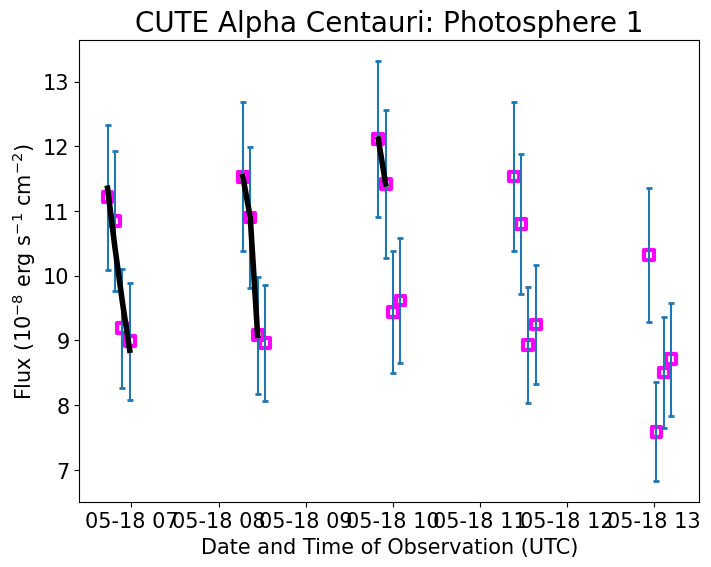

In [8]:
#Combine all the corrected flux values from all the orbits
#Photosphere 1
corflux4  = corr14
corflux4  = np.append(corflux4,corr24) 
corflux4  = np.append(corflux4,corr34)
corflux4  = np.append(corflux4,corr44) 
corflux4  = np.append(corflux4,corr54) 
#Photosphere 2
corflux42 = corr142 
corflux42 = np.append(corflux42,corr242)
corflux42 = np.append(corflux42,corr342)
corflux42 = np.append(corflux42,corr442)
corflux42 = np.append(corflux42,corr542)
#Chromosphere
corflux43 = corr143
corflux43 = np.append(corflux43,corr243) 
corflux43 = np.append(corflux43,corr343)
corflux43 = np.append(corflux43,corr443)
corflux43 = np.append(corflux43,corr543)

#Photosphere 1
#Plot the uncorrected vs corrected flux for all orbits in visit 4
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 1'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_ylim(0,7)
ax.scatter(dates4,phot1_4*1.e8, label='Visit #4: Observed flux', marker='s',edgecolors='magenta',s=50,facecolors='none',linewidths=3)
ax.errorbar(dates4,phot1_4*1.e8, yerr=0.1*phot1_4*1.e8,linestyle='none',capthick=2,capsize=2)
ax.plot(dates4[0:4], poly14*norm14*1.e8, color='black', label='Polynomial Fit',lw=4)
ax.plot(dates4[4:7], poly24*norm24*1.e8, color='black',lw=4)
ax.plot(dates4[8:10], poly44*norm44*1.e8, color='black',lw=4)
ax.scatter(dates4,corflux4*1.3*1.e8, label='Corrected Flux x 1.3', marker='s',edgecolors='cyan',s=50,facecolors='none',linewidths=3)
ax.errorbar(dates4,corflux4*1.3*1.e8, yerr=0.1*corflux4*1.3*1.E8,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()
# figname='Phot1_fluxCUTE_visit4_polyfit_werr2.jpeg'
# plt.savefig(figname,format='jpeg',dpi=200)
#plt.show()



In [9]:
#---------------------------------------------    
#Visit 5    
#Try polyfit for each visit at a time
for i in range(nfiles5):
    flux           = cute_ff5[:,i]
    ww             = cute_wavesol-8
    ind            = np.where((ww >= 2550) & (ww <= 3255))
    fluxtot        = integrate.simpson(flux[ind],ww[ind])
    totflux5[i]    = fluxtot
    ind2           = np.where((ww >= 2550) & (ww < 2790))
    fluxtot        = integrate.simpson(flux[ind2],ww[ind2])
    phot1_5[i]     = fluxtot
    flux1          = cute_ff5_sigup[:,i]
    phot1_5sigup[i]= integrate.simpson(flux1[ind2],ww[ind2]) - fluxtot
    flux2          = cute_ff5_sigdn[:,i]
    phot1_5sigdn[i]= fluxtot - integrate.simpson(flux2[ind2],ww[ind2])
    ind3           = np.where((ww >= 2790) & (ww <= 2805))
    fluxtot        = integrate.simpson(flux[ind3],ww[ind3])
    chrom5[i]      = fluxtot
    chrom5_sigup[i]= integrate.simpson(flux1[ind3],ww[ind3]) - fluxtot
    chrom5_sigdn[i]= fluxtot - integrate.simpson(flux2[ind3],ww[ind3])
    ind4           = np.where((ww > 2805) & (ww <= 3255))
    fluxtot        = integrate.simpson(flux[ind4],ww[ind4])
    phot2_5[i]     = fluxtot
    phot2_5sigup[i]= integrate.simpson(flux1[ind4],ww[ind4]) - fluxtot
    phot2_5sigdn[i]= fluxtot - integrate.simpson(flux1[ind4],ww[ind4])
    

In [10]:
#Refer to Visit 4 for an explanation of the arrays and the steps
tarr15   = timearr5[0:4]
farr15   = phot1_5[0:4] 
farr152  = phot2_5[0:4]
farr153  = chrom5[0:4]
result11 = np.polyfit(tarr15,farr15,2) 
result21 = np.polyfit(tarr15,farr152,2)
result31 = np.polyfit(tarr15,farr153,2)
poly15   = result11[0]*tarr15**2 + result11[1]*tarr15 + result11[2]
poly152  = result21[0]*tarr15**2 + result21[1]*tarr15 + result21[2]
poly153  = result31[0]*tarr15**2 + result31[1]*tarr15 + result31[2]
norm15   = poly15.max()
norm152  = poly152.max()
norm153  = poly153.max()
poly15   = poly15/norm15 
poly152  = poly152/norm152 
poly153  = poly153/norm153 
corr15   = farr15/poly15
corr152  = farr152/poly152
corr153  = farr153/poly153

tarr25  = timearr5[4:8]
farr25  = phot1_5[4:8] 
farr252 = phot2_5[4:8]
farr253 = chrom5[4:8]
result12 = np.polyfit(tarr25,farr25,2) 
result22 = np.polyfit(tarr25,farr252,2)
result32 = np.polyfit(tarr25,farr253,2)
poly25  = result12[0]*tarr25**2 + result12[1]*tarr25 + result12[2]
poly252 = result22[0]*tarr25**2 + result22[1]*tarr25 + result22[2]
poly253 = result32[0]*tarr25**2 + result32[1]*tarr25 + result32[2]
norm25  = poly25.max()
norm252 = poly252.max()
norm253 = poly253.max()
poly25  = poly25/norm25
poly252 = poly252/norm252 
poly253 = poly253/norm253 
corr25  = farr25/poly25
corr252 = farr252/poly252
corr253 = farr253/poly253

tarr35  = timearr5[8:12]
farr35  = phot1_5[8:12] 
farr352 = phot2_5[8:12]
farr353 = chrom5[8:12]
result13 = np.polyfit(tarr35,farr35,2)
result23 = np.polyfit(tarr35,farr352,2)
result33 = np.polyfit(tarr35,farr353,2) 
poly35  = result13[0]*tarr35**2 + result13[1]*tarr35 + result13[2]
poly352 = result23[0]*tarr35**2 + result23[1]*tarr35 + result23[2]
poly353 = result33[0]*tarr35**2 + result33[1]*tarr35 + result33[2]
norm35  = poly35.max()
norm352 = poly352.max()
norm353 = poly353.max()
poly35  = poly35/norm35
poly352 = poly352/norm352 
poly353 = poly353/norm353 
corr35  = farr35/poly35
corr352 = farr352/poly352
corr353 = farr353/poly353

tarr45  = timearr5[12:15]
farr45  = phot1_5[12:15] 
farr452 = phot2_5[12:15]
farr453 = chrom5[12:15]
result14 = np.polyfit(tarr45,farr45,2) 
result24 = np.polyfit(tarr45,farr452,2)
result34 = np.polyfit(tarr45,farr453,2)
poly45  = result14[0]*tarr45**2 + result14[1]*tarr45 + result14[2]
poly452 = result24[0]*tarr45**2 + result24[1]*tarr45 + result24[2]
poly453 = result34[0]*tarr45**2 + result34[1]*tarr45 + result34[2]
norm45  = poly45.max()
norm452 = poly452.max()
norm453 = poly453.max()
poly45  = poly45/norm45
poly452 = poly452/norm452 
poly453 = poly453/norm453 
corr45  = farr45/poly45
corr452 = farr452/poly452
corr453 = farr453/poly453

tarr55  = timearr5[15:20]
farr55  = phot1_5[15:19] 
farr552 = phot2_5[15:19]
farr553 = chrom5[15:19]
result15 = np.polyfit(tarr55,farr55,2) 
result25 = np.polyfit(tarr55,farr552,2)
result35 = np.polyfit(tarr55,farr553,2)
poly55  = result15[0]*tarr55**2 + result15[1]*tarr55 + result15[2]
poly552 = result25[0]*tarr55**2 + result25[1]*tarr55 + result25[2]
poly553 = result35[0]*tarr55**2 + result35[1]*tarr55 + result35[2]
norm55  = poly55.max()
norm552 = poly552.max()
norm553 = poly553.max()
poly55  = poly55/norm55
poly552 = poly552/norm552 
poly553 = poly553/norm553 
corr55  = farr55/poly55
corr552 = farr552/poly552
corr553 = farr553/poly553

tarr65  = timearr5[19:23]
farr65  = phot1_5[19:23] 
farr652 = phot2_5[19:23]
farr653 = chrom5[19:23]
result16 = np.polyfit(tarr65,farr65,2) 
result26 = np.polyfit(tarr65,farr652,2)
result36 = np.polyfit(tarr65,farr653,2)
poly65  = result16[0]*tarr65**2 + result16[1]*tarr65 + result16[2]
poly652 = result26[0]*tarr65**2 + result26[1]*tarr65 + result26[2]
poly653 = result36[0]*tarr65**2 + result36[1]*tarr65 + result36[2]
norm65  = poly65.max()
norm652 = poly652.max()
norm653 = poly653.max()
poly65  = poly65/norm65
poly652 = poly652/norm652 
poly653 = poly653/norm653 
corr65  = farr65/poly65
corr652 = farr652/poly652
corr653 = farr653/poly653

tarr75  = timearr5[23:27]
farr75  = phot1_5[23:27] 
farr752 = phot2_5[23:27]
farr753 = chrom5[23:27]
result17 = np.polyfit(tarr75,farr75,2) 
result27 = np.polyfit(tarr75,farr752,2)
result37 = np.polyfit(tarr75,farr753,2)
poly75  = result17[0]*tarr75**2 + result17[1]*tarr75 + result17[2]
poly752 = result27[0]*tarr75**2 + result27[1]*tarr75 + result27[2]
poly753 = result37[0]*tarr75**2 + result37[1]*tarr75 + result37[2]
norm75  = poly75.max()
norm752 = poly752.max()
norm753 = poly753.max()
poly75  = poly75/norm75
poly752 = poly752/norm752 
poly753 = poly753/norm753 
corr75  = farr75/poly75
corr752 = farr752/poly752
corr753 = farr753/poly753

corflux5  = np.concatenate((corr15,corr25,corr35))
corflux52 = np.concatenate((corr152,corr252,corr352))
corflux53 = np.concatenate((corr153,corr253,corr353))
corflux5  = np.append(corflux5,corr45) 
corflux5  = np.append(corflux5,corr55) 
corflux5  = np.append(corflux5,corr65) 
corflux5  = np.append(corflux5,corr75) 
corflux5  = np.append(corflux5,phot1_5[27])
corflux52 = np.append(corflux52,corr452)
corflux52 = np.append(corflux52,corr552)
corflux52 = np.append(corflux52,corr652)
corflux52 = np.append(corflux52,corr752)
corflux52 = np.append(corflux52,phot2_5[27])
corflux53 = np.append(corflux53,corr453) 
corflux53 = np.append(corflux53,corr553) 
corflux53 = np.append(corflux53,corr653) 
corflux53 = np.append(corflux53,corr753) 
corflux53 = np.append(corflux53,chrom5[27])

TypeError: expected x and y to have same length

NameError: name 'poly75' is not defined

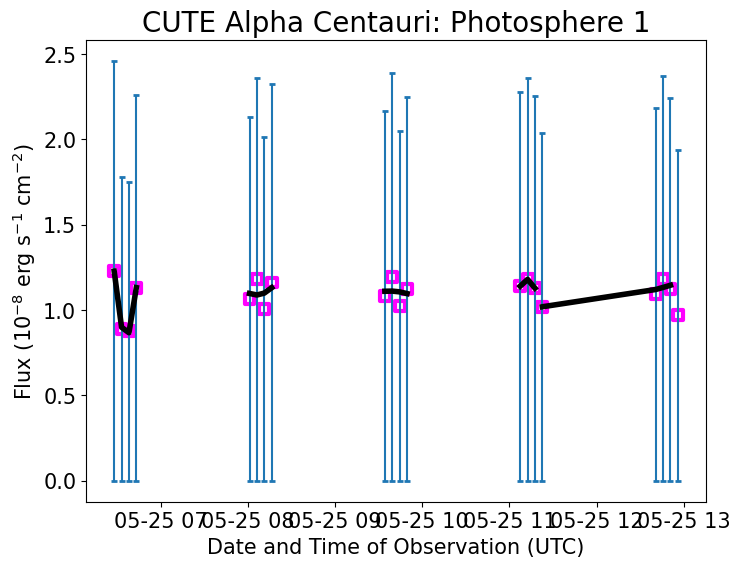

In [16]:
# Photosphere 1
#Plot the uncorrected vs corrected flux for all orbits in visit 5
y_err = [phot1_5sigdn*1.E8,phot1_5sigup*1.E8]
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 1'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_ylim(0,7)
ax.scatter(dates5,phot1_5*1.e7, label='Visit #5: Observed flux', marker='s',edgecolors='magenta',s=50,facecolors='none',linewidths=3)
ax.errorbar(dates5,phot1_5*1.e7, yerr=0.1*phot1_5*1.E8,linestyle='none',capthick=2,capsize=2)
ax.plot(dates5[0:4], poly15*norm15*1.e7, color='black', label='Polynomial Fit',lw=4)
ax.plot(dates5[4:8], poly25*norm25*1.e7, color='black',lw=4)
ax.plot(dates5[8:12], poly35*norm35*1.e7, color='black',lw=4)
ax.plot(dates5[12:15], poly45*norm45*1.e7, color='black',lw=4)
ax.plot(dates5[15:19], poly55*norm55*1.e7, color='black',lw=4)
ax.plot(dates5[19:23], poly65*norm65*1.e7, color='black',lw=4)
ax.plot(dates5[23:27], poly75*norm75*1.e7, color='black',lw=4)
ax.scatter(dates5,corflux5*1.3*1.e7, label='Corrected Flux x 1.3', marker='s',edgecolors='cyan',s=50,facecolors='none',linewidths=3)
ax.errorbar(dates5,corflux5*1.3*1.e7, yerr=0.1*corflux5*1.3*1.E8,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()
figname='Phot1_fluxCUTE_visit5_polyfit.jpeg'
plt.savefig(figname,format='jpeg',dpi=200)
#plt.show()

In [17]:
#---------------------------------------------    
#Visit 6    
#Try polyfit for each visit at a time
for i in range(nfiles6):
    flux        = cute_ff6[:,i]
    ww          = cute_wavesol-2
    ind         = np.where((ww >= 2550) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind],ww[ind])
    totflux6[i] = fluxtot
    ind2        = np.where((ww >= 2550) & (ww < 2790))
    fluxtot     = integrate.simpson(flux[ind2],ww[ind2])
    phot1_6[i]  = fluxtot
    ind3        = np.where((ww >= 2790) & (ww <= 2805))
    fluxtot     = integrate.simpson(flux[ind3],ww[ind3])
    chrom6[i]   = fluxtot
    ind4        = np.where((ww > 2805) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind4],ww[ind4])
    phot2_6[i]  = fluxtot

#Refer to Visit 4 for an explanation of the arrays and the steps
tarr16   = timearr6[0:4]
farr16   = phot1_6[0:4] 
farr162  = phot2_6[0:4]
farr163  = chrom6[0:4]
result11 = np.polyfit(tarr16,farr16,2) 
result21 = np.polyfit(tarr16,farr162,2)
result31 = np.polyfit(tarr16,farr163,2)
poly16   = result11[0]*tarr16**2 + result11[1]*tarr16 + result11[2]
poly162  = result21[0]*tarr16**2 + result21[1]*tarr16 + result21[2]
poly163  = result31[0]*tarr16**2 + result31[1]*tarr16 + result31[2]
norm16   = poly16.max()
norm162  = poly162.max()
norm163  = poly163.max()
poly16   = poly16/norm16 
poly162  = poly162/norm162 
poly163  = poly163/norm163 
corr16   = farr16/poly16
corr162  = farr162/poly162
corr163  = farr163/poly163

tarr26  = timearr6[4:8]
farr26  = phot1_6[4:8] 
farr262 = phot2_6[4:8]
farr263 = chrom6[4:8]
result12 = np.polyfit(tarr26,farr26,2) 
result22 = np.polyfit(tarr26,farr262,2)
result32 = np.polyfit(tarr26,farr263,2)
poly26  = result12[0]*tarr26**2 + result12[1]*tarr26 + result12[2]
poly262 = result22[0]*tarr26**2 + result22[1]*tarr26 + result22[2]
poly263 = result32[0]*tarr26**2 + result32[1]*tarr26 + result32[2]
norm26  = poly26.max()
norm262 = poly262.max()
norm263 = poly263.max()
poly26  = poly26/norm26
poly262 = poly262/norm262 
poly263 = poly263/norm263 
corr26  = farr26/poly26
corr262 = farr262/poly262
corr263 = farr263/poly263

tarr36  = timearr6[8:12]
farr36  = phot1_6[8:12] 
farr362 = phot2_6[8:12]
farr363 = chrom6[8:12]
result13 = np.polyfit(tarr36,farr36,2)
result23 = np.polyfit(tarr36,farr362,2)
result33 = np.polyfit(tarr36,farr363,2) 
poly36  = result13[0]*tarr36**2 + result13[1]*tarr36 + result13[2]
poly362 = result23[0]*tarr36**2 + result23[1]*tarr36 + result23[2]
poly363 = result33[0]*tarr36**2 + result33[1]*tarr36 + result33[2]
norm36  = poly36.max()
norm362 = poly362.max()
norm363 = poly363.max()
poly36  = poly36/norm36
poly362 = poly362/norm362 
poly363 = poly363/norm363 
corr36  = farr36/poly36
corr362 = farr362/poly362
corr363 = farr363/poly363

tarr46  = timearr6[12:15]
farr46  = phot1_6[12:15] 
farr462 = phot2_6[12:15]
farr463 = chrom6[12:15]
result14 = np.polyfit(tarr46,farr46,2) 
result24 = np.polyfit(tarr46,farr462,2)
result34 = np.polyfit(tarr46,farr463,2)
poly46  = result14[0]*tarr46**2 + result14[1]*tarr46 + result14[2]
poly462 = result24[0]*tarr46**2 + result24[1]*tarr46 + result24[2]
poly463 = result34[0]*tarr46**2 + result34[1]*tarr46 + result34[2]
norm46  = poly46.max()
norm462 = poly462.max()
norm463 = poly463.max()
poly46  = poly46/norm46
poly462 = poly462/norm462 
poly463 = poly463/norm463 
corr46  = farr46/poly46
corr462 = farr462/poly462
corr463 = farr463/poly463

tarr56  = timearr6[15:19]
farr56  = phot1_6[15:19] 
farr562 = phot2_6[15:19]
farr563 = chrom6[15:19]
result15 = np.polyfit(tarr56,farr56,2) 
result25 = np.polyfit(tarr56,farr562,2)
result35 = np.polyfit(tarr56,farr563,2)
poly56  = result15[0]*tarr56**2 + result15[1]*tarr56 + result15[2]
poly562 = result25[0]*tarr56**2 + result25[1]*tarr56 + result25[2]
poly563 = result35[0]*tarr56**2 + result35[1]*tarr56 + result35[2]
norm56  = poly56.max()
norm562 = poly562.max()
norm563 = poly563.max()
poly56  = poly56/norm56
poly562 = poly562/norm562 
poly563 = poly563/norm563 
corr56  = farr56/poly56
corr562 = farr562/poly562
corr563 = farr563/poly563

tarr66  = timearr6[19:23]
farr66  = phot1_6[19:23] 
farr662 = phot2_6[19:23]
farr663 = chrom6[19:23]
result16 = np.polyfit(tarr66,farr66,2) 
result26 = np.polyfit(tarr66,farr662,2)
result36 = np.polyfit(tarr66,farr663,2)
poly66  = result16[0]*tarr66**2 + result16[1]*tarr66 + result16[2]
poly662 = result26[0]*tarr66**2 + result26[1]*tarr66 + result26[2]
poly663 = result36[0]*tarr66**2 + result36[1]*tarr66 + result36[2]
norm66  = poly66.max()
norm662 = poly662.max()
norm663 = poly663.max()
poly66  = poly66/norm66
poly662 = poly662/norm662 
poly663 = poly663/norm663 
corr66  = farr66/poly66
corr662 = farr662/poly662
corr663 = farr663/poly663

tarr76  = timearr6[23:27]
farr76  = phot1_6[23:27] 
farr762 = phot2_6[23:27]
farr763 = chrom6[23:27]
result17 = np.polyfit(tarr76,farr76,2) 
result27 = np.polyfit(tarr76,farr762,2)
result37 = np.polyfit(tarr76,farr763,2)
poly76  = result17[0]*tarr76**2 + result17[1]*tarr76 + result17[2]
poly762 = result27[0]*tarr76**2 + result27[1]*tarr76 + result27[2]
poly763 = result37[0]*tarr76**2 + result37[1]*tarr76 + result37[2]
norm76  = poly76.max()
norm762 = poly762.max()
norm763 = poly763.max()
poly76  = poly76/norm76
poly762 = poly762/norm762 
poly763 = poly763/norm763 
corr76  = farr76/poly76
corr762 = farr762/poly762
corr763 = farr763/poly763

tarr86  = timearr6[27:31]
farr86  = phot1_6[27:31] 
farr862 = phot2_6[27:31]
farr863 = chrom6[27:31]
result18 = np.polyfit(tarr86,farr86,2) 
result28 = np.polyfit(tarr86,farr862,2)
result38 = np.polyfit(tarr86,farr863,2)
poly86  = result18[0]*tarr86**2 + result18[1]*tarr86 + result18[2]
poly862 = result28[0]*tarr86**2 + result28[1]*tarr86 + result28[2]
poly863 = result38[0]*tarr86**2 + result38[1]*tarr86 + result38[2]
norm86  = poly86.max()
norm862 = poly862.max()
norm863 = poly863.max()
poly86  = poly86/norm86
poly862 = poly862/norm862 
poly863 = poly863/norm863 
corr86  = farr86/poly86
corr862 = farr862/poly862
corr863 = farr863/poly863

corflux6  = np.concatenate((corr16,corr26,corr36))
corflux62 = np.concatenate((corr162,corr262,corr362))
corflux63 = np.concatenate((corr163,corr263,corr363))
corflux6  = np.append(corflux6,corr46) 
corflux6  = np.append(corflux6,corr56) 
corflux6  = np.append(corflux6,corr66) 
corflux6  = np.append(corflux6,corr76) 
corflux6  = np.append(corflux6,corr86) 
corflux62 = np.append(corflux62,corr462)
corflux62 = np.append(corflux62,corr562)
corflux62 = np.append(corflux62,corr662)
corflux62 = np.append(corflux62,corr762)
corflux62 = np.append(corflux62,corr862)
corflux63 = np.append(corflux63,corr463) 
corflux63 = np.append(corflux63,corr563) 
corflux63 = np.append(corflux63,corr663) 
corflux63 = np.append(corflux63,corr763) 
corflux63 = np.append(corflux63,corr863) 
 
#Photosphere 1
#Plot the uncorrected vs corrected flux for all orbits in visit 6
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri vis 6: Photosphere 1'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
ax.set_ylim(0,6)
ax.scatter(dates6,phot1_6*1.e8, label='Visit #6: Observed flux', marker='s',edgecolors='blue',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates6,phot1_6*1.e8, yerr=0.1*phot1_6*1.e8,linestyle='none',capthick=2,capsize=2)
ax.plot(dates6[0:4], poly16*norm16*1.e8, color='red', label='Polynomial Fit',lw=2)
ax.plot(dates6[4:8], poly26*norm26*1.e8, color='red',lw=2)
ax.plot(dates6[8:12], poly36*norm36*1.e8, color='red',lw=2)
ax.plot(dates6[12:15], poly46*norm46*1.e8, color='red',lw=2)
ax.plot(dates6[15:19], poly56*norm56*1.e8, color='red',lw=2)
ax.plot(dates6[19:23], poly66*norm66*1.e8, color='red',lw=2)
ax.plot(dates6[23:27], poly76*norm76*1.e8, color='red',lw=2)
ax.plot(dates6[27:31], poly86*norm86*1.e8, color='red',lw=2)
ax.scatter(dates6,corflux6*1.3*1.e8, label='Corrected Flux x 1.3', marker='s',edgecolors='darkorange',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates6,corflux6*1.3*1.e8, yerr=0.1*corflux6*1.3*1.e8,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()
figname='Phot1_fluxCUTE_visit6_polyfit.jpeg'
plt.savefig(figname,format='jpeg',dpi=200)
plt.show()

#Photosphere 2
#Plot the uncorrected vs corrected flux for all orbits in visit 6
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri vis 6: Photosphere 2'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-7}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_ylim(0,2.5)
ax.scatter(dates6,phot2_6*1.e7, label='Visit #6: Observed flux', marker='^',edgecolors='blue',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates6,phot2_6*1.e7, yerr=0.1*phot2_6*1.e7,linestyle='none',capthick=2,capsize=2)
ax.plot(dates6[0:4], poly162*norm162*1.e7, color='red', label='Polynomial Fit',lw=2)
ax.plot(dates6[4:8], poly262*norm262*1.e7, color='red',lw=2)
ax.plot(dates6[8:12], poly362*norm362*1.e7, color='red',lw=2)
ax.plot(dates6[12:15], poly462*norm462*1.e7, color='red',lw=2)
ax.plot(dates6[15:19], poly562*norm562*1.e7, color='red',lw=2)
ax.plot(dates6[19:23], poly662*norm662*1.e7, color='red',lw=2)
ax.plot(dates6[23:27], poly762*norm762*1.e7, color='red',lw=2)
ax.plot(dates6[27:31], poly862*norm862*1.e7, color='red',lw=2)
ax.scatter(dates6,corflux62*1.3*1.e7, label='Corrected Flux x 1.3', marker='^',edgecolors='darkorange',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates6,corflux62*1.3*1.e7, yerr=0.1*corflux62*1.3*1.e7,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()
figname='Phot2_fluxCUTE_visit6_polyfit.jpeg'
plt.savefig(figname,format='jpeg',dpi=200)
plt.show()

#Chromosphere
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri vis 6: Chromosphere'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_ylim(0,3.0)
ax.scatter(dates6,chrom6*1.e9, label='Visit #6: Observed flux', marker='D',edgecolors='blue',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates6,chrom6*1.e9, yerr=0.1*chrom6*1.e9,linestyle='none',capthick=2,capsize=2)
ax.plot(dates6[0:4], poly163*norm163*1.e9, color='red', label='Polynomial Fit',lw=2)
ax.plot(dates6[4:8], poly263*norm263*1.e9, color='red',lw=2)
ax.plot(dates6[8:12], poly363*norm363*1.e9, color='red',lw=2)
ax.plot(dates6[12:15], poly463*norm463*1.e9, color='red',lw=2)
ax.plot(dates6[15:19], poly563*norm563*1.e9, color='red',lw=2)
ax.plot(dates6[19:23], poly663*norm663*1.e9, color='red',lw=2)
ax.plot(dates6[23:27], poly763*norm763*1.e9, color='red',lw=2)
ax.plot(dates6[27:31], poly863*norm863*1.e9, color='red',lw=2)
ax.scatter(dates6,corflux63*1.3*1.e9, label='Corrected Flux x 1.3', marker='D',edgecolors='darkorange',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates6,corflux63*1.3*1.e9, yerr=0.1*corflux63*1.3*1.e9,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()
figname='/Chrom_fluxCUTE_visit6_polyfit.jpeg'
plt.savefig(figname,format='jpeg',dpi=200)
plt.show()

#Plotting the corrected Photosphere 1, Photosphere 2 and Chromosphere for visit 6
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri Observations: Visit #6'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
ax.set_yscale('log')
ax.scatter(dates6,corflux6, label='Photosphere 1', marker='s',edgecolors='cyan',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates6,corflux6, yerr=0.1*corflux6,linestyle='none',capthick=2,capsize=2)
ax.scatter(dates6,corflux62, label='Photosphere 2', marker='^',edgecolors='magenta',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates6,corflux62, yerr=0.1*corflux62,linestyle='none',capthick=2,capsize=2)
ax.scatter(dates6,corflux63, label='Chromosphere', marker='D',edgecolors='darkorange',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates6,corflux63, yerr=0.1*corflux63,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,bbox_to_anchor=(0.4,0.5))
fig.tight_layout()
figname='Chrom_fluxCUTE_visit6_correctedall.jpeg'
plt.savefig(figname,format='jpeg',dpi=200)
plt.show()

TypeError: expected non-empty vector for x

## Visit 7

In [26]:
#---------------------------------------------    
#Visit 7    
#Try polyfit for each visit at a time

for i in range(nfiles7):
    flux        = cute_ff7[:,i]
    ww          = cute_wavesol-9
    ind         = np.where((ww >= 2550) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind],ww[ind])
    totflux7[i] = fluxtot
    ind2        = np.where((ww >= 2550) & (ww < 2790))
    fluxtot     = integrate.simpson(flux[ind2],ww[ind2])
    phot1_7[i]  = fluxtot
    ind3        = np.where((ww >= 2790) & (ww <= 2805))
    fluxtot     = integrate.simpson(flux[ind3],ww[ind3])
    chrom7[i]   = fluxtot
    ind4        = np.where((ww > 2805) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind4],ww[ind4])
    phot2_7[i]  = fluxtot
    
#Refer to Visit 4 for an explanation of the arrays and the steps
tarr17   = timearr7[0:4]
farr17   = phot1_7[0:4] 
farr172  = phot2_7[0:4]
farr173  = chrom7[0:4]
result11 = np.polyfit(tarr17,farr17,2) 
result21 = np.polyfit(tarr17,farr172,2)
result31 = np.polyfit(tarr17,farr173,2)
poly17   = result11[0]*tarr17**2 + result11[1]*tarr17 + result11[2]
poly172  = result21[0]*tarr17**2 + result21[1]*tarr17 + result21[2]
poly173  = result31[0]*tarr17**2 + result31[1]*tarr17 + result31[2]
norm17   = poly17.max()
norm172  = poly172.max()
norm173  = poly173.max()
poly17   = poly17/norm17 
poly172  = poly172/norm172 
poly173  = poly173/norm173 
corr17   = farr17/poly17
corr172  = farr172/poly172
corr173  = farr173/poly173

tarr27   = timearr7[4:8]
farr27   = phot1_7[4:8] 
farr272  = phot2_7[4:8]
farr273  = chrom7[4:8]
result12 = np.polyfit(tarr27,farr27,2) 
result22 = np.polyfit(tarr27,farr272,2)
result32 = np.polyfit(tarr27,farr273,2)
poly27   = result12[0]*tarr27**2 + result12[1]*tarr27 + result12[2]
poly272  = result22[0]*tarr27**2 + result22[1]*tarr27 + result22[2]
poly273  = result32[0]*tarr27**2 + result32[1]*tarr27 + result32[2]
norm27   = poly27.max()
norm272  = poly272.max()
norm273  = poly273.max()
poly27   = poly27/norm27
poly272  = poly272/norm272 
poly273  = poly273/norm273 
corr27   = farr27/poly27
corr272  = farr272/poly272
corr273  = farr273/poly273

tarr37   = timearr7[8:12]
farr37   = phot1_7[8:12] 
farr372  = phot2_7[8:12]
farr373  = chrom7[8:12]
result13 = np.polyfit(tarr37,farr37,2)
result23 = np.polyfit(tarr37,farr372,2)
result33 = np.polyfit(tarr37,farr373,2) 
poly37   = result13[0]*tarr37**2 + result13[1]*tarr37 + result13[2]
poly372  = result23[0]*tarr37**2 + result23[1]*tarr37 + result23[2]
poly373  = result33[0]*tarr37**2 + result33[1]*tarr37 + result33[2]
norm37   = poly37.max()
norm372  = poly372.max()
norm373  = poly373.max()
poly37   = poly37/norm37
poly372  = poly372/norm372 
poly373  = poly373/norm373 
corr37   = farr37/poly37
corr372  = farr372/poly372
corr373  = farr373/poly373

tarr47   = timearr7[12:16]
farr47   = phot1_7[12:16] 
farr472  = phot2_7[12:16]
farr473  = chrom7[12:16]
result14 = np.polyfit(tarr47,farr47,2) 
result24 = np.polyfit(tarr47,farr472,2)
result34 = np.polyfit(tarr47,farr473,2)
poly47   = result14[0]*tarr47**2 + result14[1]*tarr47 + result14[2]
poly472  = result24[0]*tarr47**2 + result24[1]*tarr47 + result24[2]
poly473  = result34[0]*tarr47**2 + result34[1]*tarr47 + result34[2]
norm47   = poly47.max()
norm472  = poly472.max()
norm473  = poly473.max()
poly47   = poly47/norm47
poly472  = poly472/norm472 
poly473  = poly473/norm473 
corr47   = farr47/poly47
corr472  = farr472/poly472
corr473  = farr473/poly473

tarr57   = timearr7[16:20]
farr57   = phot1_7[16:20] 
farr572  = phot2_7[16:20]
farr573  = chrom7[16:20]
result15 = np.polyfit(tarr57,farr57,2) 
result25 = np.polyfit(tarr57,farr572,2)
result35 = np.polyfit(tarr57,farr573,2)
poly57   = result15[0]*tarr57**2 + result15[1]*tarr57 + result15[2]
poly572  = result25[0]*tarr57**2 + result25[1]*tarr57 + result25[2]
poly573  = result35[0]*tarr57**2 + result35[1]*tarr57 + result35[2]
norm57   = poly57.max()
norm572  = poly572.max()
norm573  = poly573.max()
poly57   = poly57/norm57
poly572  = poly572/norm572 
poly573  = poly573/norm573 
corr57   = farr57/poly57
corr572  = farr572/poly572
corr573  = farr573/poly573

tarr67   = timearr7[20:24]
farr67   = phot1_7[20:24] 
farr672  = phot2_7[20:24]
farr673  = chrom7[20:24]
result16 = np.polyfit(tarr67,farr67,2) 
result26 = np.polyfit(tarr67,farr672,2)
result36 = np.polyfit(tarr67,farr673,2)
poly67   = result16[0]*tarr67**2 + result16[1]*tarr67 + result16[2]
poly672  = result26[0]*tarr67**2 + result26[1]*tarr67 + result26[2]
poly673  = result36[0]*tarr67**2 + result36[1]*tarr67 + result36[2]
norm67   = poly67.max()
norm672  = poly672.max()
norm673  = poly673.max()
poly67   = poly67/norm67
poly672  = poly672/norm672 
poly673  = poly673/norm673 
corr67   = farr67/poly67
corr672  = farr672/poly672
corr673  = farr673/poly673

tarr77   = timearr7[24:28]
farr77   = phot1_7[24:28] 
farr772  = phot2_7[24:28]
farr773  = chrom7[24:28]
result17 = np.polyfit(tarr77,farr77,2) 
result27 = np.polyfit(tarr77,farr772,2)
result37 = np.polyfit(tarr77,farr773,2)
poly77   = result17[0]*tarr77**2 + result17[1]*tarr77 + result17[2]
poly772  = result27[0]*tarr77**2 + result27[1]*tarr77 + result27[2]
poly773  = result37[0]*tarr77**2 + result37[1]*tarr77 + result37[2]
norm77   = poly77.max()
norm772  = poly772.max()
norm773  = poly773.max()
poly77   = poly77/norm77
poly772  = poly772/norm772 
poly773  = poly773/norm773 
corr77   = farr77/poly77
corr772  = farr772/poly772
corr773  = farr773/poly773


corr87    = phot1_7[28]
corr872   = phot2_7[28]
corr873   = chrom7[28]

corflux7  = np.concatenate((corr17,corr27,corr37,corr47,corr57,corr67,corr77))
corflux72 = np.concatenate((corr172,corr272,corr372,corr472,corr572,corr672,corr772))
corflux73 = np.concatenate((corr173,corr273,corr373,corr473,corr573,corr673,corr773))
corflux7  = np.append(corflux7,corr87) 
corflux72 = np.append(corflux72,corr872)
corflux73 = np.append(corflux73,corr873)  


#Photosphere 1
#Plot the uncorrected vs corrected flux for all orbits in visit 7
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 1'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
ax.set_ylim(0,6)
ax.scatter(dates7,phot1_7*1.e8, label='Visit #7: Observed flux', marker='s',edgecolors='darkred',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates7,phot1_7*1.e8, yerr=0.1*phot1_7*1.e8,linestyle='none',capthick=2,capsize=2)
ax.plot(dates7[0:4], poly17*norm17*1.e8, color='blue', label='Polynomial Fit',lw=2)
ax.plot(dates7[4:8], poly27*norm27*1.e8, color='blue',lw=2)
ax.plot(dates7[8:12], poly37*norm37*1.e8, color='blue',lw=2)
ax.plot(dates7[12:16], poly47*norm47*1.e8, color='blue',lw=2)
ax.plot(dates7[16:20], poly57*norm57*1.e8, color='blue',lw=2)
ax.plot(dates7[20:24], poly67*norm67*1.e8, color='blue',lw=2)
ax.plot(dates7[24:28], poly77*norm77*1.e8, color='blue',lw=2)
ax.scatter(dates7,corflux7*1.3*1.e8, label='Corrected Flux x 1.3', marker='s',edgecolors='green',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates7,corflux7*1.3*1.e8, yerr=0.1*corflux7*1.3*1.e8,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()
figname='Phot1_fluxCUTE_visit7_polyfit.jpeg'
plt.savefig(figname,format='jpeg',dpi=200)
plt.show()

#Photosphere 2
#Plot the uncorrected vs corrected flux for all orbits in visit 7
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri vis 7: Photosphere 2'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-7}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
ax.set_ylim(0,2.5)
ax.scatter(dates7,phot2_7*1.e7, label='Visit #7: Observed flux', marker='^',edgecolors='darkred',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates7,phot2_7*1.e7, yerr=0.1*phot2_7*1.e7,linestyle='none',capthick=2,capsize=2)
ax.plot(dates7[0:4], poly172*norm172*1.e7, color='blue', label='Polynomial Fit',lw=2)
ax.plot(dates7[4:8], poly272*norm272*1.e7, color='blue',lw=2)
ax.plot(dates7[8:12], poly372*norm372*1.e7, color='blue',lw=2)
ax.plot(dates7[12:16], poly472*norm472*1.e7, color='blue',lw=2)
ax.plot(dates7[16:20], poly572*norm572*1.e7, color='blue',lw=2)
ax.plot(dates7[20:24], poly672*norm672*1.e7, color='blue',lw=2)
ax.plot(dates7[24:28], poly772*norm772*1.e7, color='blue',lw=2)
ax.scatter(dates7,corflux72*1.3*1.e7, label='Corrected Flux x 1.3', marker='^',edgecolors='green',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates7,corflux72*1.3*1.e7, yerr=0.1*corflux72*1.3*1.e7,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()
figname='Phot2_fluxCUTE_visit7_polyfit.jpeg'
plt.savefig(figname,format='jpeg',dpi=200)
plt.show()

#Chromosphere
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri vis 7: Chromosphere'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
# ax.set_ylim(0,3.0)
ax.scatter(dates7,chrom7*1.e9, label='Visit #7, orbit1: Observed flux', marker='D',edgecolors='darkred',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates7,chrom7*1.e9, yerr=0.1*chrom7*1.e9,linestyle='none',capthick=2,capsize=2)
ax.plot(dates7[0:4], poly173*norm173*1.e9, color='blue', label='Polynomial Fit',lw=2)
ax.plot(dates7[4:8], poly273*norm273*1.e9, color='blue',lw=2)
ax.plot(dates7[8:12], poly373*norm373*1.e9, color='blue',lw=2)
ax.plot(dates7[12:16], poly473*norm473*1.e9, color='blue',lw=2)
ax.plot(dates7[16:20], poly573*norm573*1.e9, color='blue',lw=2)
ax.plot(dates7[20:24], poly673*norm673*1.e9, color='blue',lw=2)
ax.plot(dates7[24:28], poly773*norm773*1.e9, color='blue',lw=2)
ax.scatter(dates7,corflux73*1.3*1.e9, label='Corrected Flux x 1.3', marker='D',edgecolors='green',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates7,corflux73*1.3*1.e9, yerr=0.1*corflux73*1.3*1.e9,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()
figname='Chrom_fluxCUTE_visit7_polyfit.jpeg'
plt.savefig(figname,format='jpeg',dpi=200)
plt.show()


#Plotting the corrected Photosphere 1, Photosphere 2 and Chromosphere for visit 7
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri Observations: Visit #7'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
ax.set_yscale('log')
ax.scatter(dates7,corflux7, label='Photosphere 1', marker='s',edgecolors='green',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates7,corflux7, yerr=0.1*corflux7,linestyle='none',capthick=2,capsize=2)
ax.scatter(dates7,corflux72, label='Photosphere 2', marker='^',edgecolors='darkred',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates7,corflux72, yerr=0.1*corflux72,linestyle='none',capthick=2,capsize=2)
ax.scatter(dates7,corflux73, label='Chromosphere', marker='D',edgecolors='darkblue',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates7,corflux73, yerr=0.1*corflux73,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,bbox_to_anchor=(0.4,0.5))
fig.tight_layout()
figname='Chrom_fluxCUTE_visit7.jpeg'
plt.savefig(figname,format='jpeg')

TypeError: expected non-empty vector for x

## Visit 8

ValueError: x and y must be the same size

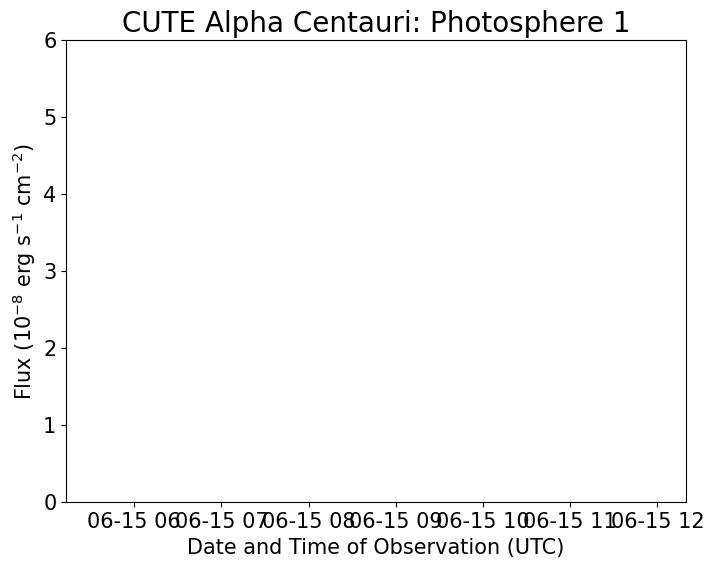

In [22]:
#Visit 8    
#Try polyfit for each visit at a time

for i in range(nfiles8):
    flux        = cute_ff8[:,i]
    ww          = cute_wavesol-2
    ind         = np.where((ww >= 2550) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind],ww[ind])
    totflux8[i] = fluxtot
    ind2        = np.where((ww >= 2550) & (ww < 2790))
    fluxtot     = integrate.simpson(flux[ind2],ww[ind2])
    phot1_8[i]  = fluxtot
    ind3        = np.where((ww >= 2790) & (ww <= 2805))
    fluxtot     = integrate.simpson(flux[ind3],ww[ind3])
    chrom8[i]   = fluxtot
    ind4        = np.where((ww > 2805) & (ww <= 3255))
    fluxtot     = integrate.simpson(flux[ind4],ww[ind4])
    phot2_8[i]  = fluxtot

#Refer to Visit 4 for an explanation of the arrays and the steps
tarr18   = timearr8[0:4]
farr18   = phot1_8[0:4] 
farr182  = phot2_8[0:4]
farr183  = chrom8[0:4]
result11 = np.polyfit(tarr18,farr18,2) 
result21 = np.polyfit(tarr18,farr182,2)
result31 = np.polyfit(tarr18,farr183,2)
poly18   = result11[0]*tarr18**2 + result11[1]*tarr18 + result11[2]
poly182  = result21[0]*tarr18**2 + result21[1]*tarr18 + result21[2]
poly183  = result31[0]*tarr18**2 + result31[1]*tarr18 + result31[2]
norm18   = poly18.max()
norm182  = poly182.max()
norm183  = poly183.max()
poly18   = poly18/norm18 
poly182  = poly182/norm182 
poly183  = poly183/norm183 
corr18   = farr18/poly18
corr182  = farr182/poly182
corr183  = farr183/poly183

tarr28   = timearr8[4:8]
farr28   = phot1_8[4:8] 
farr282  = phot2_8[4:8]
farr283  = chrom8[4:8]
result12 = np.polyfit(tarr28,farr28,2) 
result22 = np.polyfit(tarr28,farr282,2)
result32 = np.polyfit(tarr28,farr283,2)
poly28   = result12[0]*tarr28**2 + result12[1]*tarr28 + result12[2]
poly282  = result22[0]*tarr28**2 + result22[1]*tarr28 + result22[2]
poly283  = result32[0]*tarr28**2 + result32[1]*tarr28 + result32[2]
norm28   = poly28.max()
norm282  = poly282.max()
norm283  = poly283.max()
poly28   = poly28/norm28
poly282  = poly282/norm282 
poly283  = poly283/norm283 
corr28   = farr28/poly28
corr282  = farr282/poly282
corr283  = farr283/poly283

tarr38   = timearr8[8:12]
farr38   = phot1_8[8:12] 
farr382  = phot2_8[8:12]
farr383  = chrom8[8:12]
result13 = np.polyfit(tarr38,farr38,2)
result23 = np.polyfit(tarr38,farr382,2)
result33 = np.polyfit(tarr38,farr383,2) 
poly38   = result13[0]*tarr38**2 + result13[1]*tarr38 + result13[2]
poly382  = result23[0]*tarr38**2 + result23[1]*tarr38 + result23[2]
poly383  = result33[0]*tarr38**2 + result33[1]*tarr38 + result33[2]
norm38   = poly38.max()
norm382  = poly382.max()
norm383  = poly383.max()
poly38   = poly38/norm38
poly382  = poly382/norm382 
poly383  = poly383/norm383 
corr38   = farr38/poly38
corr382  = farr382/poly382
corr383  = farr383/poly383

tarr48   = timearr8[12:16]
farr48   = phot1_8[12:16] 
farr482  = phot2_8[12:16]
farr483  = chrom8[12:16]
result14 = np.polyfit(tarr48,farr48,2) 
result24 = np.polyfit(tarr48,farr482,2)
result34 = np.polyfit(tarr48,farr483,2)
poly48   = result14[0]*tarr48**2 + result14[1]*tarr48 + result14[2]
poly482  = result24[0]*tarr48**2 + result24[1]*tarr48 + result24[2]
poly483  = result34[0]*tarr48**2 + result34[1]*tarr48 + result34[2]
norm48   = poly48.max()
norm482  = poly482.max()
norm483  = poly483.max()
poly48   = poly48/norm48
poly482  = poly482/norm482 
poly483  = poly483/norm483 
corr48   = farr48/poly48
corr482  = farr482/poly482
corr483  = farr483/poly483

corr58    = phot1_8[16]
corr582   = phot2_8[16]
corr583   = chrom8[16]

corflux8  = np.concatenate((corr18,corr28,corr38))
corflux82 = np.concatenate((corr182,corr282,corr382))
corflux83 = np.concatenate((corr183,corr283,corr383))
corflux8  = np.append(corflux8,corr48) 
corflux82 = np.append(corflux82,corr482)
corflux83 = np.append(corflux83,corr483) 
corflux8  = np.append(corflux8,corr58) 
corflux82 = np.append(corflux82,corr582)
corflux83 = np.append(corflux83,corr583) 

#Photosphere 1
#Plot the uncorrected vs corrected flux for all orbits in visit 8
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 1'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
ax.set_ylim(0,6)
ax.scatter(dates8,phot1_8*1.e8, label='Visit #8: Observed flux', marker='s',edgecolors='palegoldenrod',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates8,phot1_8*1.e8, yerr=0.1*phot1_8*1.e8,linestyle='none',capthick=2,capsize=2)
ax.plot(dates8[0:4], poly18*norm18*1.e8, color='black', label='Polynomial Fit',lw=2)
ax.plot(dates8[4:8], poly28*norm28*1.e8, color='black',lw=2)
ax.plot(dates8[8:12], poly38*norm38*1.e8, color='black',lw=2)
ax.plot(dates8[12:16], poly48*norm48*1.e8, color='black',lw=2)
ax.scatter(dates8,corflux8*1.3*1.e8, label='Corrected Flux x 1.3', marker='s',edgecolors='mediumorchid',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates8,corflux8*1.3*1.e8, yerr=0.1*corflux8*1.3*1.e8,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()
figname='Phot1_fluxCUTE_visit8_polyfit.jpeg'
plt.savefig(figname,format='jpeg',dpi=200)
plt.show()

#Photosphere 2
#Plot the uncorrected vs corrected flux for all orbits in visit 8
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Photosphere 2'
ax.set_title(title,fontsize=20)
ax.tick_params
ax.scatter(dates8,phot2_8*1.e7, label='Visit #8: Observed flux', marker='^',edgecolors='palegoldenrod',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates8,phot2_8*1.e7, yerr=0.1*phot2_8*1.e7,linestyle='none',capthick=2,capsize=2)
ax.plot(dates8[0:4], poly182*norm172*1.e7, color='black', label='Polynomial Fit',lw=2)
ax.plot(dates8[4:8], poly282*norm272*1.e7, color='black',lw=2)
ax.plot(dates8[8:12], poly382*norm372*1.e7, color='black',lw=2)
ax.plot(dates8[12:16], poly482*norm472*1.e7, color='black',lw=2)
ax.scatter(dates8,corflux82*1.3*1.e7, label='Corrected Flux x 1.3', marker='^',edgecolors='mediumorchid',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates8,corflux82*1.3*1.e7, yerr=0.1*corflux82*1.3*1.e7,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()
figname='Phot2_fluxCUTE_visit8_polyfit.jpeg'
plt.savefig(figname,format='jpeg',dpi=200)
plt.show()

#Chromosphere
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri: Chromosphere'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
ax.set_ylim(0,3.0)
ax.scatter(dates8,chrom8*1.e9, label='Visit #8, orbit1: Observed flux', marker='D',edgecolors='palegoldenrod',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates8,chrom8*1.e9, yerr=0.1*chrom8*1.e9,linestyle='none',capthick=2,capsize=2)
ax.plot(dates8[0:4], poly183*norm183*1.e9, color='black', label='Polynomial Fit',lw=2)
ax.plot(dates8[4:8], poly283*norm283*1.e9, color='black',lw=2)
ax.plot(dates8[8:12], poly383*norm383*1.e9, color='black',lw=2)
ax.plot(dates8[12:16], poly483*norm483*1.e9, color='black',lw=2)
ax.scatter(dates8,corflux83*1.*1.e9, label='Corrected Flux x 1.3', marker='D',edgecolors='mediumorchid',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates8,corflux83*1.3*1.e9, yerr=0.1*corflux83*1.3*1.e9,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,loc=3)
fig.tight_layout()
figname='Chrom_fluxCUTE_visit8_polyfit.jpeg'
plt.savefig(figname,format='jpeg',dpi=200)
plt.show()

#Plotting the corrected Photosphere 1, Photosphere 2 and Chromosphere for visit 8
fig,ax = plt.subplots(figsize=(8,6))
title  = 'CUTE Alpha Centauri Observations: Visit #8'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15) 
ax.set_xlabel('Date and Time of Observation (UTC)',fontsize=15)
ax.set_ylabel('Flux (erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
ax.set_yscale('log')
ax.scatter(dates8,corflux8, label='Photosphere 1', marker='s',edgecolors='green',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates8,corflux8, yerr=0.1*corflux8,linestyle='none',capthick=2,capsize=2)
ax.scatter(dates8,corflux82, label='Photosphere 2', marker='^',edgecolors='darkred',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates8,corflux82, yerr=0.1*corflux82,linestyle='none',capthick=2,capsize=2)
ax.scatter(dates8,corflux83, label='Chromosphere', marker='D',edgecolors='darkblue',s=100,facecolors='none',linewidths=3)
ax.errorbar(dates8,corflux83, yerr=0.1*corflux83,linestyle='none',capthick=2,capsize=2)
# Format x-axis
date_format = mdates.DateFormatter("%Y-%m-%d %H:%M")  # Customize format as needed
ax.xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)  # Rotate labels if needed
ax.legend(fontsize=15,bbox_to_anchor=(0.4,0.5))
fig.tight_layout()
figname='Chrom_fluxCUTE_visit8_correctedall.jpeg'
plt.savefig(figname,format='jpeg',dpi=200)
plt.show()


In [23]:

#Attempting to combine visits again
#For the time being plotting against dates is problematic. So just plotting all visits against observation #

alldtstr = []
alldtstr = np.append(alldtstr,dt4str)
alldtstr = np.append(alldtstr,dt5str)
alldtstr = np.append(alldtstr,dt6str)
alldtstr = np.append(alldtstr,dt7str)
alldtstr = np.append(alldtstr,dt8str)
alldtstr = np.array(alldtstr)
allphot1 = corflux4
allphot1 = np.append(allphot1,corflux5)
allphot1 = np.append(allphot1,corflux6)
allphot1 = np.append(allphot1,corflux7)
allphot1 = np.append(allphot1,corflux8)
xnum     = np.arange(len(allphot1))

nf4 = nfiles4
nf5 = nfiles5
nf6 = nfiles6
nf7 = nfiles7
nf8 = nfiles8

#Photosphere1
fig,ax = plt.subplots(figsize=(10,5))
title  = 'CUTE Alpha Centauri: Photosphere 1'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Observation #',fontsize=15)
ax.set_ylabel('Flux (10$^{-8}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
ax.set_ylim(0,20)
ax.scatter(xnum[0:nf4],allphot1[0:nf4]*1.e8, label = 'Visit #4',marker='D',edgecolors='darkkhaki',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[0:nf4],allphot1[0:nf4]*1.e8, yerr=0.1*allphot1[0:nf4]*1.e8,linestyle='none',capthick=2,capsize=2,color='black')
ax.scatter(xnum[nf4:nf4+nf5],allphot1[nf4:nf4+nf5]*1.e8, label = 'Visit #5',marker='D',edgecolors='darkred',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[nf4:nf4+nf5],allphot1[nf4:nf4+nf5]*1.e8, yerr=0.1*allphot1[nf4:nf4+nf5]*1.e8,linestyle='none',capthick=2,capsize=2,color='black')
ax.scatter(xnum[nf4+nf5:nf4+nf5+nf6],allphot1[nf4+nf5:nf4+nf5+nf6]*1.E8, label = 'Visit #6',marker='D',edgecolors='blue',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[nf4+nf5:nf4+nf5+nf6],allphot1[nf4+nf5:nf4+nf5+nf6]*1.e8, yerr=0.1*allphot1[nf4+nf5:nf4+nf5+nf6]*1.e8,linestyle='none',capthick=2,capsize=2,color='black')
ax.scatter(xnum[nf4+nf5+nf6:nf4+nf5+nf6+nf7],allphot1[nf4+nf5+nf6:nf4+nf5+nf6+nf7]*1.E8, label='Visit #7',marker='D',edgecolors='green',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[nf4+nf5+nf6:nf4+nf5+nf6+nf7],allphot1[nf4+nf5+nf6:nf4+nf5+nf6+nf7]*1.e8, yerr=0.1*allphot1[nf4+nf5+nf6:nf4+nf5+nf6+nf7]*1.e8,linestyle='none',capthick=2,capsize=2,color='black')
ax.scatter(xnum[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8],allphot1[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8]*1.E8, label='Visit #8',marker='D',edgecolors='magenta',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8],allphot1[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8]*1.e8, yerr=0.1*allphot1[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8]*1.e8,linestyle='none',capthick=2,capsize=2,color='black')
legend = ax.legend(fontsize=14,loc=3)
fig.tight_layout()
figname='Phot1_fluxCUTE_correctedall_werr2.jpeg'
plt.savefig(figname,format='jpeg',dpi=200)


#Photosphere 2
allphot2 = corflux42
allphot2 = np.append(allphot2,corflux52)
allphot2 = np.append(allphot2,corflux62)
allphot2 = np.append(allphot2,corflux72)
allphot2 = np.append(allphot2,corflux82)
xnum     = np.arange(len(allphot2))

#Photosphere2
fig,ax = plt.subplots(figsize=(10,5))
title  = 'CUTE Alpha Centauri: Photosphere 2'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Observation #',fontsize=15)
ax.set_ylabel('Flux (10$^{-7}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
ax.set_ylim(0,2.5)
ax.scatter(xnum[0:nf4],allphot2[0:nf4]*1.e7, label = 'Visit #4',marker='D',edgecolors='seagreen',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[0:nf4],allphot2[0:nf4]*1.e7, yerr=0.1*allphot2[0:nf4]*1.e7,linestyle='none',capthick=2,capsize=2,color='black')
ax.scatter(xnum[nf4:nf4+nf5],allphot2[nf4:nf4+nf5]*1.e7, label = 'Visit #5',marker='D',edgecolors='dimgrey',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[nf4:nf4+nf5],allphot2[nf4:nf4+nf5]*1.e7, yerr=0.1*allphot2[nf4:nf4+nf5]*1.e7,linestyle='none',capthick=2,capsize=2,color='black')
ax.scatter(xnum[nf4+nf5:nf4+nf5+nf6],allphot2[nf4+nf5:nf4+nf5+nf6]*1.E7, label = 'Visit #6',marker='D',edgecolors='indigo',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[nf4+nf5:nf4+nf5+nf6],allphot2[nf4+nf5:nf4+nf5+nf6]*1.e7, yerr=0.1*allphot2[nf5:nf5+nf6]*1.e7,linestyle='none',capthick=2,capsize=2,color='black')
ax.scatter(xnum[nf4+nf5+nf6:nf4+nf5+nf6+nf7],allphot2[nf4+nf5+nf6:nf4+nf5+nf6+nf7]*1.E7, label='Visit #7',marker='D',edgecolors='gold',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[nf4+nf5+nf6:nf4+nf5+nf6+nf7],allphot2[nf4+nf5+nf6:nf4+nf5+nf6+nf7]*1.e7, yerr=0.1*allphot2[nf4+nf5+nf6:nf4+nf5+nf6+nf7]*1.e7,linestyle='none',capthick=2,capsize=2,color='black')
ax.scatter(xnum[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8],allphot2[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8]*1.E7, label='Visit #8',marker='D',edgecolors='indianred',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8],allphot2[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8]*1.e7, yerr=0.1*allphot2[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8]*1.e7,linestyle='none',capthick=2,capsize=2,color='black')
legend = ax.legend(fontsize=14,loc=3)
fig.tight_layout()
figname='Phot2_fluxCUTE_correctedall.jpeg'
plt.savefig(figname,format='jpeg',dpi=200)
plt.show()


#Chromosphere
allchrom = corflux43
allchrom = np.append(allchrom,corflux53)
allchrom = np.append(allchrom,corflux63)
allchrom = np.append(allchrom,corflux73)
allchrom = np.append(allchrom,corflux83)
xnum     = np.arange(len(allchrom))

fig,ax = plt.subplots(figsize=(10,5))
title  = 'CUTE Alpha Centauri: Chromosphere'
ax.set_title(title,fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Observation #',fontsize=15)
ax.set_ylabel('Flux (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$)',fontsize=15)
ax.set_ylim(0,10)
ax.scatter(xnum[0:nf4],allchrom[0:nf4]*1.e9, label = 'Visit #4',marker='D',edgecolors='pink',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[0:nf4],allchrom[0:nf4]*1.e9, yerr=0.1*allchrom[0:nf4]*1.e9,linestyle='none',capthick=2,capsize=2,color='black')
ax.scatter(xnum[nf4:nf4+nf5],allchrom[nf4:nf4+nf5]*1.e9, label = 'Visit #5',marker='D',edgecolors='olive',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[nf4:nf4+nf5],allchrom[nf4:nf4+nf5]*1.e9, yerr=0.1*allchrom[nf4:nf4+nf5]*1.e9,linestyle='none',capthick=2,capsize=2,color='black')
ax.scatter(xnum[nf4+nf5:nf4+nf5+nf6],allchrom[nf4+nf5:nf4+nf5+nf6]*1.E9, label = 'Visit #6',marker='D',edgecolors='cadetblue',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[nf4+nf5:nf4+nf5+nf6],allchrom[nf4+nf5:nf4+nf5+nf6]*1.e9, yerr=0.1*allchrom[nf4+nf5:nf4+nf5+nf6]*1.e9,linestyle='none',capthick=2,capsize=2,color='black')
ax.scatter(xnum[nf4+nf5+nf6:nf4+nf5+nf6+nf7],allchrom[nf4+nf5+nf6:nf4+nf5+nf6+nf7]*1.E9, label='Visit #7',marker='D',edgecolors='darkorange',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[nf4+nf5+nf6:nf4+nf5+nf6+nf7],allchrom[nf4+nf5+nf6:nf4+nf5+nf6+nf7]*1.e9, yerr=0.1*allchrom[nf4+nf5+nf6:nf4+nf5+nf6+nf7]*1.e9,linestyle='none',capthick=2,capsize=2,color='black')
ax.scatter(xnum[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8],allchrom[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8]*1.E9, label='Visit #8',marker='D',edgecolors='mediumaquamarine',s=100,facecolors='none',linewidths=3)
ax.errorbar(xnum[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8],allchrom[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8]*1.e9, yerr=0.1*allchrom[nf4+nf5+nf6+nf7:nf4+nf5+nf6+nf7+nf8]*1.e9,linestyle='none',capthick=2,capsize=2,color='black')
legend = ax.legend(fontsize=14,loc=3)
fig.tight_layout()
figname='Chrom_fluxCUTE_correctedall_werr2.jpeg'
plt.savefig(figname,format='jpeg',dpi=200)
plt.show()

NameError: name 'corflux5' is not defined

In [24]:
phot1_flux = np.array(allphot1)
phot2_flus = np.array(allphot2)
chrom_flux = np.array(allchrom)

time_arr = (timearr4 , timearr5, timearr6, timearr7, timearr8)


NameError: name 'allphot2' is not defined

In [25]:
from astropy.time import Time

# alldtstr is your list/array of observation times as strings
time_mjd = Time(alldtstr, format="iso").mjd
phot1_flux = np.array(allphot1)
phot2_flux = np.array(allphot2)
chrom_flux = np.array(allchrom)


NameError: name 'allphot2' is not defined

(0.0, 40.0)

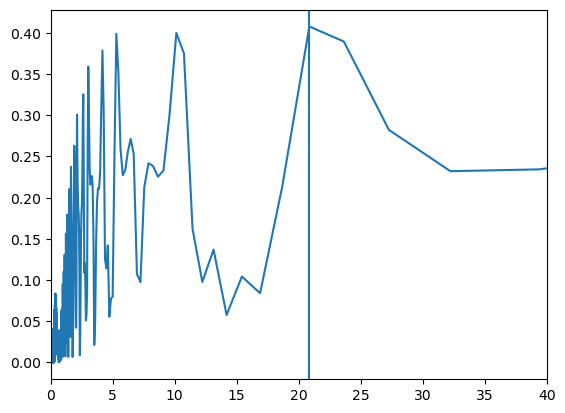

In [296]:
from astropy.timeseries import LombScargle

ls = LombScargle(time_mjd , allchrom)
freq , power =ls.autopower(method='slow')

best_period = 1/freq[np.argmax(power)]
plt.axvline(best_period)
plt.plot(1/freq, power)
plt.xlim(0,40)



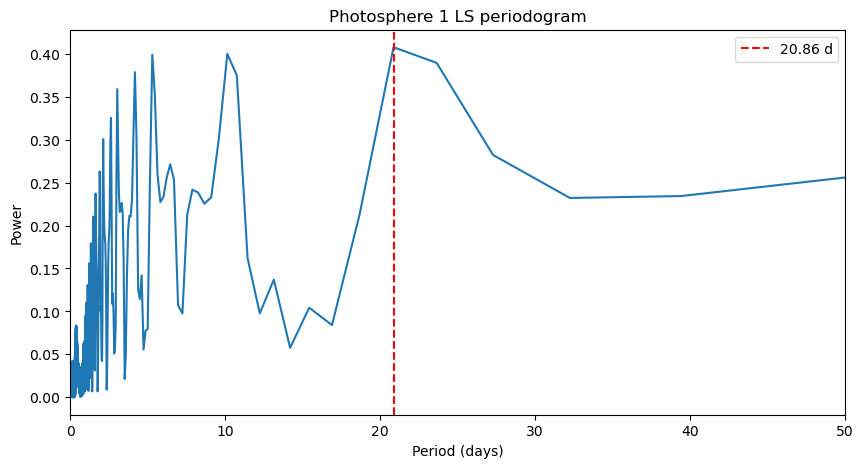

In [297]:
from astropy.timeseries import LombScargle
import matplotlib.pyplot as plt
import numpy as np

# Photosphere 1 light curve
# plt.figure(figsize=(10,5))
# plt.plot(time_mjd, chrom_flux, "o-")
# plt.xlabel("MJD")
# plt.ylabel("Flux (erg/s/cm^2)")
# plt.title("Photosphere 1 light curve")
# plt.show()

# Lomb–Scargle periodogram
ls = LombScargle(time_mjd, chrom_flux)
freq, power = ls.autopower()
best_period = 1/freq[np.argmax(power)]

plt.figure(figsize=(10,5))
plt.plot(1/freq, power)
plt.axvline(best_period, color="red", ls="--", label=f"{best_period:.2f} d")
plt.xlabel("Period (days)")
plt.ylabel("Power")
plt.xlim(0,50)
plt.title("Photosphere 1 LS periodogram")
plt.legend()
plt.show()


In [ ]:
print(phot1_flux)

## Inspections

In [299]:
# from astropy.timeseries import lombscargle 


# ls  = lombscargle()



Correlations (pearson r): phot2-chrom = 0.882 (p=3.9e-38), phot1-chrom = 0.946 (p=5.5e-56), phot1-phot2 = 0.962


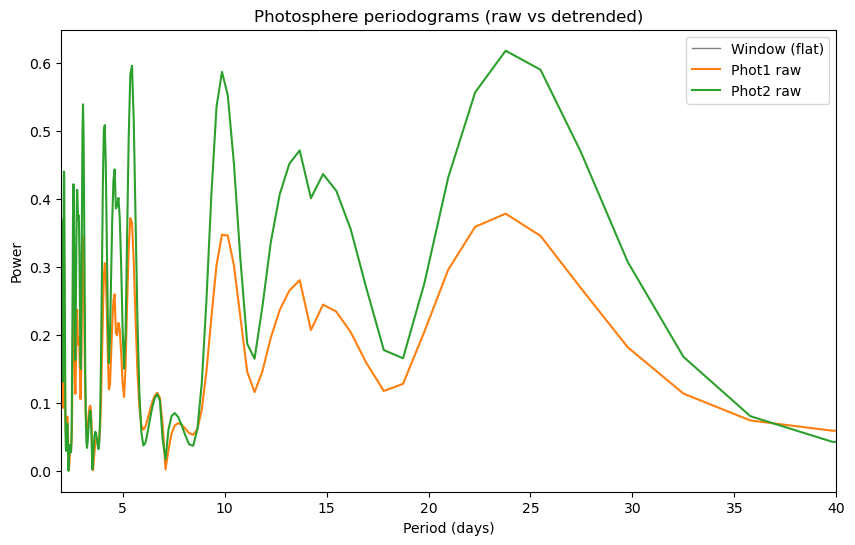

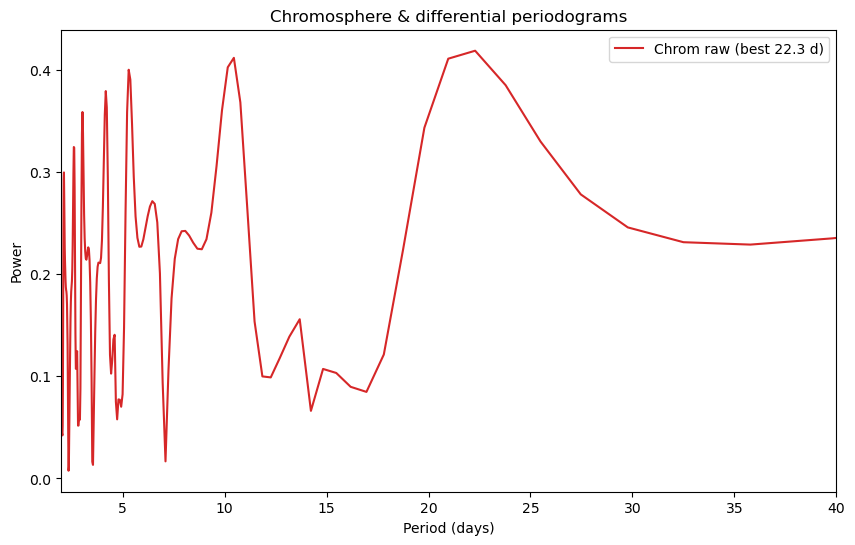

Running a quick shuffle test for Phot2 (this may take a little while)...


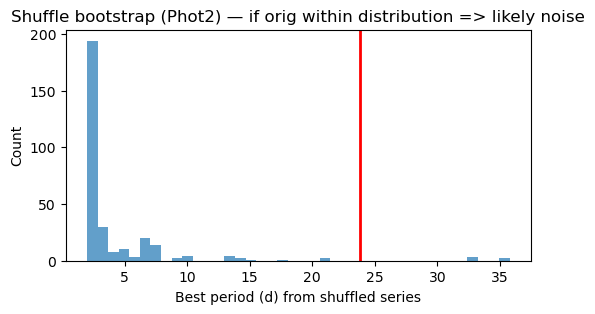

Phase-folds (detrended chrom and differential):


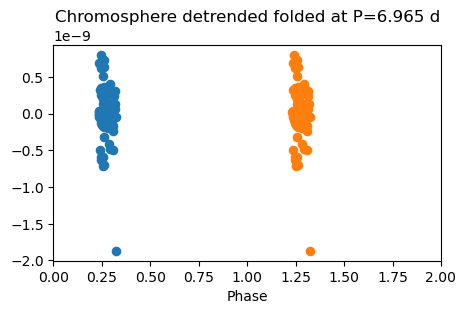

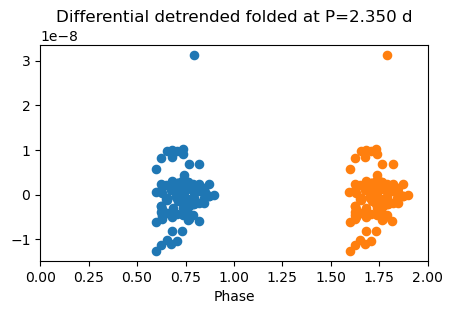

In [317]:
# === Diagnostics to prove photosphere peaks are artifacts and chromosphere is real ===
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
from scipy.stats import pearsonr
import random

# === Input arrays (replace with your arrays if not already in workspace) ===
# time_mjd = ...
# phot1_flux = ...
# phot2_flux = ...
# chrom_flux = ...

# --- helper: run LS and return best period + power + arrays ---
def run_ls(t, y, perfreq=None, min_p=2, max_p=60):
    mask = np.isfinite(t) & np.isfinite(y)
    t0, y0 = t[mask], y[mask]
    if len(t0) < 6:
        return None
    ls = LombScargle(t0, y0)
    if perfreq is None:
        freq, power = ls.autopower(minimum_frequency=1/max_p, maximum_frequency=1/min_p, samples_per_peak=10)
    else:
        freq, power = ls.autopower()
    period = 1.0 / freq
    idx = np.argmax(power)
    return {'ls': ls, 't': t0, 'y': y0, 'freq': freq, 'period': period, 'power': power,
            'bestP': period[idx], 'bestPower': power[idx]}

# 1) Per-visit mean subtraction (detrend by visits)
# define visits by large gaps
gap_thresh = 0.3   # days; adjust if needed
visit_id = np.cumsum(np.diff(time_mjd, prepend=time_mjd[0]) > gap_thresh)
phot1_det = phot1_flux.copy()
phot2_det = phot2_flux.copy()
chrom_det = chrom_flux.copy()
for v in np.unique(visit_id):
    mask = visit_id == v
    if mask.sum() > 0:
        phot1_det[mask] = phot1_det[mask] - np.mean(phot1_det[mask])
        phot2_det[mask] = phot2_det[mask] - np.mean(phot2_det[mask])
        chrom_det[mask] = chrom_det[mask] - np.mean(chrom_det[mask])

# 2) Window function (flat signal sampled at same times)
flat = np.ones_like(time_mjd)
res_window = run_ls(time_mjd, flat)

# 3) raw/detrended LS runs
res_ph1_raw = run_ls(time_mjd, phot1_flux)
res_ph1_det = run_ls(time_mjd, phot1_det)
res_ph2_raw = run_ls(time_mjd, phot2_flux)
res_ph2_det = run_ls(time_mjd, phot2_det)
res_chrom_raw = run_ls(time_mjd, chrom_flux)
res_chrom_det = run_ls(time_mjd, chrom_det)

# 4) differential series and LS
diff = chrom_flux - 0.5*(phot1_flux + phot2_flux)
diff_det = diff.copy()
# also detrend per visit for diff
for v in np.unique(visit_id):
    m = (visit_id == v)
    diff_det[m] = diff_det[m] - np.mean(diff_det[m])
res_diff = run_ls(time_mjd, diff)
res_diff_det = run_ls(time_mjd, diff_det)

# 5) correlation tests
corr_p2_ch, pval_p2_ch = pearsonr(np.nan_to_num(phot2_flux), np.nan_to_num(chrom_flux))
corr_p1_ch, pval_p1_ch = pearsonr(np.nan_to_num(phot1_flux), np.nan_to_num(chrom_flux))
corr_p1_p2, pval_p1_p2 = pearsonr(np.nan_to_num(phot1_flux), np.nan_to_num(phot2_flux))

print("Correlations (pearson r): phot2-chrom = %.3f (p=%.1e), phot1-chrom = %.3f (p=%.1e), phot1-phot2 = %.3f" %
      (corr_p2_ch, pval_p2_ch, corr_p1_ch, pval_p1_ch, corr_p1_p2))

# 6) Window vs Phot periodograms (plot)
plt.figure(figsize=(10,6))
if res_window: plt.plot(res_window['period'], res_window['power'], color='0.5', label='Window (flat)', lw=1)
if res_ph1_raw: plt.plot(res_ph1_raw['period'], res_ph1_raw['power'], label='Phot1 raw', color='C1')
# if res_ph1_det: plt.plot(res_ph1_det['period'], res_ph1_det['power'], label='Phot1 detrended', color='C1', ls='--')
if res_ph2_raw: plt.plot(res_ph2_raw['period'], res_ph2_raw['power'], label='Phot2 raw', color='C2')
# if res_ph2_det: plt.plot(res_ph2_det['period'], res_ph2_det['power'], label='Phot2 detrended', color='C2', ls='--')
plt.xlim(2,40); plt.xlabel('Period (days)'); plt.ylabel('Power'); plt.legend(); plt.title('Photosphere periodograms (raw vs detrended)')
plt.show()

# 7) Chrom & diff periodograms (raw & detrended)
plt.figure(figsize=(10,6))
if res_chrom_raw: plt.plot(res_chrom_raw['period'], res_chrom_raw['power'], label=f'Chrom raw (best {res_chrom_raw["bestP"]:.1f} d)', color='C3')
# if res_chrom_det: plt.plot(res_chrom_det['period'], res_chrom_det['power'], label=f'Chrom detr (best {res_chrom_det["bestP"]:.1f} d)', color='C3', ls='--')
# if res_diff: plt.plot(res_diff['period'], res_diff['power'], label=f'Diff raw (best {res_diff["bestP"]:.1f} d)', color='C4')
# if res_diff_det: plt.plot(res_diff_det['period'], res_diff_det['power'], label=f'Diff detr (best {res_diff_det["bestP"]:.1f} d)', color='C4', ls='--')
plt.xlim(2,40); plt.xlabel('Period (days)'); plt.ylabel('Power'); plt.legend(); plt.title('Chromosphere & differential periodograms')
# plt.axvline(res_chrom_raw , '--', color = 'black')
plt.show()

# 8) Shuffle test for Phot2 (example)
def shuffle_test(t, y, nshuffle=500):
    bests = []
    for i in range(nshuffle):
        ysh = np.random.permutation(y)
        r = run_ls(t, ysh)
        if r:
            bests.append(r['bestP'])
    return np.array(bests)

print("Running a quick shuffle test for Phot2 (this may take a little while)...")
bests_shuf = shuffle_test(time_mjd, phot2_flux, nshuffle=300)
# compare original bestP to distribution
orig_p = res_ph2_raw['bestP'] if res_ph2_raw else np.nan
plt.figure(figsize=(6,3))
plt.hist(bests_shuf, bins=40, alpha=0.7); plt.axvline(orig_p, color='r', lw=2)
plt.xlabel('Best period (d) from shuffled series'); plt.ylabel('Count')
plt.title('Shuffle bootstrap (Phot2) — if orig within distribution => likely noise')
plt.show()

# 9) Phase-folds: Chrom and Diff at bestP (detrended)
def phase_fold_plot(rdict, label):
    if not rdict: return
    P = rdict['bestP']
    t0, y0 = rdict['t'], rdict['y']
    phi = (t0 % P)/P
    idx = np.argsort(phi)
    plt.figure(figsize=(5,2.8))
    plt.scatter(phi[idx], y0[idx], s=35); plt.scatter(phi[idx]+1, y0[idx], s=35)
    plt.title(f"{label} folded at P={P:.3f} d"); plt.xlim(0,2); plt.xlabel('Phase'); plt.show()

print("Phase-folds (detrended chrom and differential):")
phase_fold_plot(res_chrom_det, "Chromosphere detrended")
phase_fold_plot(res_diff_det, "Differential detrended")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
from scipy.signal import detrend

def run_ls(time, flux):
    """Compute LS periodogram and return periods, power, bestP"""
    ls = LombScargle(time, flux)
    freq, power = ls.autopower(
        minimum_frequency=1/40,  # ~40 d max
        maximum_frequency=1/2,   # ~2 d min
        samples_per_peak=10
    )
    period = 1 / freq
    bestP = period[np.argmax(power)]
    return period, power, bestP

# --- Detrend each flux series (simple linear detrend)
chrom_flux_dt = detrend(chrom_flux)
phot1_flux_dt = detrend(phot1_flux)
phot2_flux_dt = detrend(phot2_flux)

datasets = [
    ("Chromosphere", chrom_flux, chrom_flux_dt),
    ("Photosphere 1", phot1_flux, phot1_flux_dt),
    ("Photosphere 2", phot2_flux, phot2_flux_dt)
]

fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True, sharey=True)

for i, (label, raw, dt) in enumerate(datasets):
    # Raw
    p_raw, pow_raw, best_raw = run_ls(time_mjd, raw)
    axes[i,0].plot(p_raw, pow_raw, color="purple")
    axes[i,0].axvline(best_raw, color="red", ls="--", label=f"{best_raw:.1f} d")
    axes[i,0].set_ylabel(label)
    axes[i,0].legend()

    # Detrended
    p_dt, pow_dt, best_dt = run_ls(time_mjd, dt)
    axes[i,1].plot(p_dt, pow_dt, color="teal")
    axes[i,1].axvline(best_dt, color="red", ls="--", label=f"{best_dt:.1f} d")
    axes[i,1].legend()

axes[2,0].set_xlabel("Period (days)")
axes[2,1].set_xlabel("Period (days)")
axes[0,0].set_title("Raw flux LS")
axes[0,1].set_title("Detrended LS")

plt.tight_layout()
plt.show()


Photosphere1: mean of per-visit std = 5.449e-09, std of per-visit means = 5.463e-09
Photosphere2: mean of per-visit std = 4.162e-09, std of per-visit means = 6.703e-09
Chromosphere: mean of per-visit std = 2.770e-10, std of per-visit means = 3.220e-10


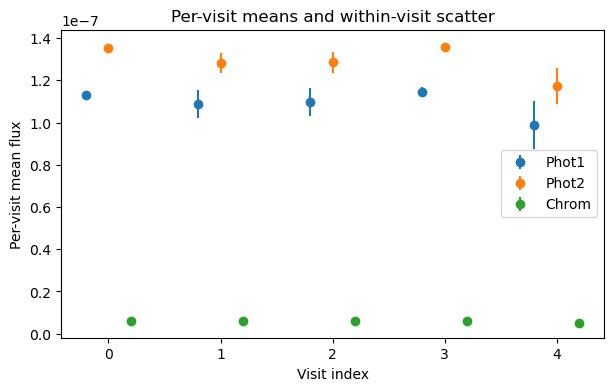

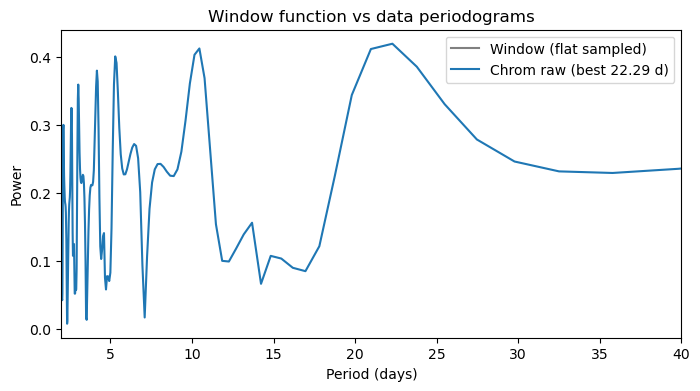

Best periods: phot1 23.78 d, phot2 23.78 d, chrom 22.29 d, window 60.00 d
Running shuffle test for Phot1 (this may take a bit)...


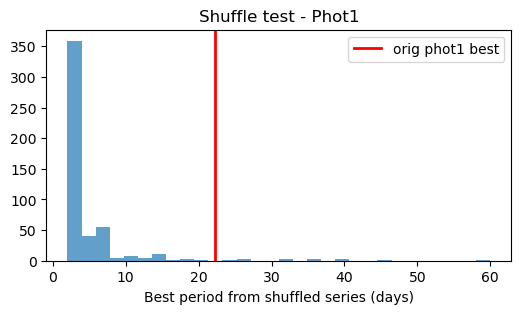

Fraction of shuffles within ±1 d of Phot1 original best: 0.002
Fraction for Phot2: 0.0
Pearson r: phot1-chrom = 0.946 (p=5.5e-56), phot2-chrom = 0.882 (p=3.9e-38), phot1-phot2 = 0.962


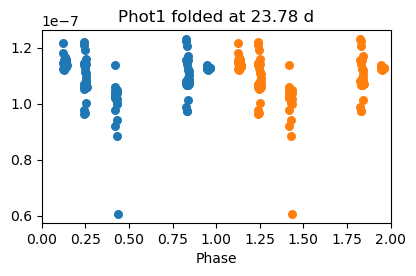

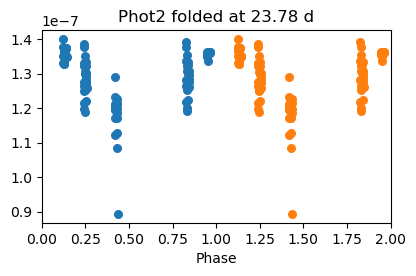

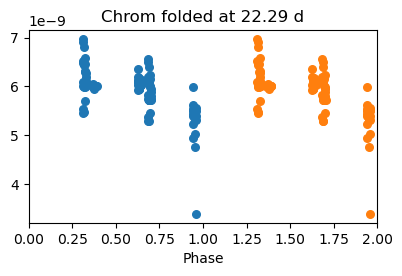

In [302]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
from scipy.stats import pearsonr

# === inputs ===
t = np.array(time_mjd)          # your MJD array
ph1 = np.array(phot1_flux)      # photosphere 1
ph2 = np.array(phot2_flux)      # photosphere 2
ch = np.array(chrom_flux)       # chromosphere

# --- helper LS ---
def best_period_and_power(time, flux, min_p=2, max_p=60):
    mask = np.isfinite(time) & np.isfinite(flux)
    ls = LombScargle(time[mask], flux[mask])
    freq, power = ls.autopower(minimum_frequency=1/max_p, maximum_frequency=1/min_p, samples_per_peak=10)
    period = 1.0 / freq
    idx = np.argmax(power)
    return period, power, period[idx], power[idx], ls

# ========== TEST 1: within-visit scatter vs between-visit offsets ==========
gap_thresh = 0.3  # days, adjust if visits separated by larger gaps
visit_id = np.cumsum(np.diff(t, prepend=t[0]) > gap_thresh)
visits = np.unique(visit_id)

def visit_stats(flux, visit_id):
    means = []
    stds = []
    counts = []
    for v in visits:
        mask = visit_id == v
        vals = flux[mask]
        if len(vals) == 0:
            continue
        means.append(np.mean(vals))
        stds.append(np.std(vals, ddof=1))
        counts.append(len(vals))
    return np.array(means), np.array(stds), np.array(counts)

means1, stds1, counts1 = visit_stats(ph1, visit_id)
means2, stds2, counts2 = visit_stats(ph2, visit_id)
meansc, stdsc, countsc = visit_stats(ch, visit_id)

print("Photosphere1: mean of per-visit std = {:.3e}, std of per-visit means = {:.3e}".format(np.mean(stds1), np.std(means1)))
print("Photosphere2: mean of per-visit std = {:.3e}, std of per-visit means = {:.3e}".format(np.mean(stds2), np.std(means2)))
print("Chromosphere: mean of per-visit std = {:.3e}, std of per-visit means = {:.3e}".format(np.mean(stdsc), np.std(meansc)))

# Plot per-visit means + scatter
plt.figure(figsize=(7,4))
x = np.arange(len(means1))
plt.errorbar(x-0.2, means1, yerr=stds1, fmt='o', label='Phot1')
plt.errorbar(x, means2, yerr=stds2, fmt='o', label='Phot2')
plt.errorbar(x+0.2, meansc, yerr=stdsc, fmt='o', label='Chrom')
plt.xlabel('Visit index'); plt.ylabel('Per-visit mean flux'); plt.legend()
plt.title('Per-visit means and within-visit scatter')
plt.show()

# Interpretation: if std(means) >> mean(stds) for photosphere => instrument offsets dominate.

# ========== TEST 2: window function (flat) ==========
period_flat, power_flat, bestP_flat, bestPow_flat, _ = best_period_and_power(t, np.ones_like(t))
period_ph1, power_ph1, bestP_ph1, bp_ph1, ls1 = best_period_and_power(t, ph1)
period_ph2, power_ph2, bestP_ph2, bp_ph2, ls2 = best_period_and_power(t, ph2)
period_ch, power_ch, bestP_ch, bp_ch, ls_ch = best_period_and_power(t, ch)

plt.figure(figsize=(8,4))
plt.plot(period_flat, power_flat, color='0.5', label='Window (flat sampled)'); plt.xlim(2,40)
# plt.plot(period_ph1, power_ph1, label=f'Phot1 raw (best {bestP_ph1:.2f} d)')
# plt.plot(period_ph2, power_ph2, label=f'Phot2 raw (best {bestP_ph2:.2f} d)')
plt.plot(period_ch, power_ch, label=f'Chrom raw (best {bestP_ch:.2f} d)')
plt.xlabel('Period (days)'); plt.ylabel('Power'); plt.legend(); plt.title('Window function vs data periodograms')
plt.show()

print("Best periods: phot1 {:.2f} d, phot2 {:.2f} d, chrom {:.2f} d, window {:.2f} d".format(bestP_ph1, bestP_ph2, bestP_ch, bestP_flat))

# If window shows peaks aligned with phot peaks ==> sampling alias.

# ========== TEST 3: shuffle / bootstrap ==========
def shuffle_test(time, flux, niter=500):
    bests = []
    for i in range(niter):
        y = np.random.permutation(flux)
        _, _, bp, _, _ = best_period_and_power(time, y)
        bests.append(bp)
    return np.array(bests)

print("Running shuffle test for Phot1 (this may take a bit)...")
bests1 = shuffle_test(t, ph1, niter=500)
plt.figure(figsize=(6,3))
plt.hist(bests1, bins=30, alpha=0.7)
plt.axvline(bestP_ch, color='r', lw=2, label='orig phot1 best')
plt.xlabel('Best period from shuffled series (days)'); plt.legend(); plt.title('Shuffle test - Phot1')
plt.show()
frac_close = np.mean(np.abs(bests1 - bestP_ph1) < 1.0)
print("Fraction of shuffles within ±1 d of Phot1 original best:", frac_close)

# Repeat for Phot2 if desired
bests2 = shuffle_test(t, ph2, niter=300)
frac_close2 = np.mean(np.abs(bests2 - bestP_ph2) < 1.0)
print("Fraction for Phot2:", frac_close2)

# Interpretation: if a large fraction (e.g. >0.05) of shuffled trials produce similar best periods,
# the original period is not special (likely noise/alias).

# ========== TEST 4: correlations with chromosphere ==========
r12, p12 = pearsonr(np.nan_to_num(ph1), np.nan_to_num(ch))
r22, p22 = pearsonr(np.nan_to_num(ph2), np.nan_to_num(ch))
r_ph12, p_ph12 = pearsonr(np.nan_to_num(ph1), np.nan_to_num(ph2))
print("Pearson r: phot1-chrom = {:.3f} (p={:.1e}), phot2-chrom = {:.3f} (p={:.1e}), phot1-phot2 = {:.3f}".format(r12, p12, r22, p22, r_ph12))

# Interpretation: high r (e.g. >0.4) means contamination or common instrument mode.

# ========== TEST 5: phase-folds for visual coherence ==========
def phase_fold(t, y, P):
    phi = (t % P) / P
    order = np.argsort(phi)
    return phi[order], y[order]

for (label, flux, bp) in [('Phot1', ph1, bestP_ph1), ('Phot2', ph2, bestP_ph2), ('Chrom', ch, bestP_ch)]:
    phi, y = phase_fold(t, flux, bp)
    plt.figure(figsize=(4.5,2.5))
    plt.scatter(phi, y, s=30); plt.scatter(phi+1, y, s=30)
    plt.title(f"{label} folded at {bp:.2f} d"); plt.xlim(0,2); plt.xlabel('Phase'); plt.show()
# For a real periodic signal you should see a smooth repeated curve; for noise the points scatter.


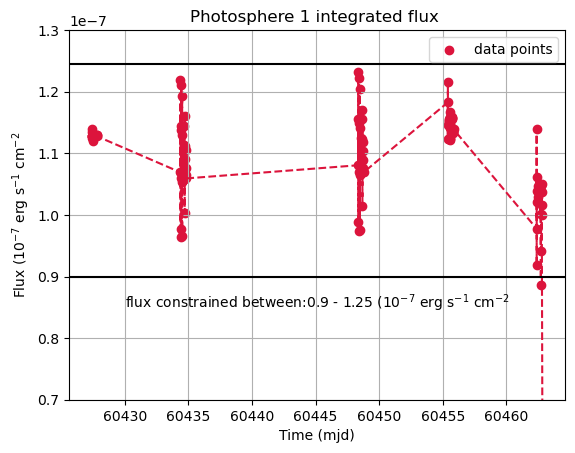

In [303]:
plt.scatter(time_mjd,allphot1, color ='crimson', label = 'data points')
plt.plot(time_mjd,allphot1, '--',color ='crimson')
plt.title('Photosphere 1 integrated flux ')
plt.xlabel('Time (mjd)')
plt.ylabel('Flux (10$^{-7}$ erg s$^{-1}$ cm$^{-2}$')
plt.grid()
plt.ylim(0.7*1e-7 , 1.3*1e-7  )
plt.axhline(1.245*1e-7, lw = 1.5 , color = 'black')
plt.axhline(0.9*1e-7, lw = 1.5 , color = 'black' )
plt.text(60430,0.85*1e-7, 'flux constrained between:0.9 - 1.25 (10$^{-7}$ erg s$^{-1}$ cm$^{-2}$')
plt.legend()


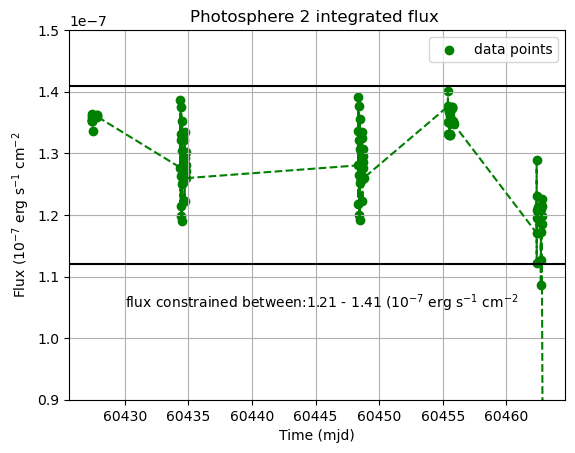

In [304]:
plt.scatter(time_mjd,allphot2, color ='green' , label= 'data points')
plt.plot(time_mjd,allphot2, '--',color ='green')
plt.title('Photosphere 2 integrated flux ')
plt.xlabel('Time (mjd)')
plt.ylabel('Flux (10$^{-7}$ erg s$^{-1}$ cm$^{-2}$')
plt.grid()
plt.ylim(0.9*1e-7 , 1.5*1e-7  )
plt.axhline(1.41*1e-7, lw = 1.5 , color = 'black')
plt.axhline(1.12*1e-7, lw = 1.5 , color = 'black' )
plt.text(60430,1.05*1e-7, 'flux constrained between:1.21 - 1.41 (10$^{-7}$ erg s$^{-1}$ cm$^{-2}$')
plt.legend()

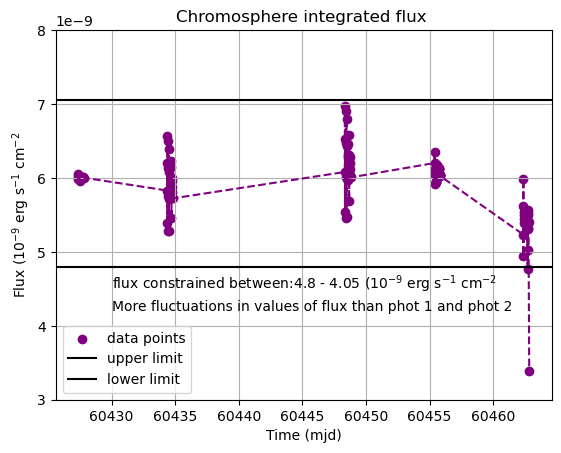

In [305]:
plt.scatter(time_mjd, allchrom , color = 'purple' , label = 'data points')
plt.plot(time_mjd, allchrom , '--',color ='purple')
plt.title('Chromosphere integrated flux ')
plt.xlabel('Time (mjd)')
plt.ylabel('Flux (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$')
plt.grid()
plt.ylim(3*1e-9 , 8*1e-9  )
plt.axhline(7.05*1e-9, lw = 1.5 , color = 'black', label = 'upper limit')
plt.axhline(4.8*1e-9, lw = 1.5 , color = 'black' , label = 'lower limit')
plt.text(60430,4.5*1e-9, 'flux constrained between:4.8 - 4.05 (10$^{-9}$ erg s$^{-1}$ cm$^{-2}$')
plt.text(60430,4.2*1e-9, 'More fluctuations in values of flux than phot 1 and phot 2')
plt.legend()

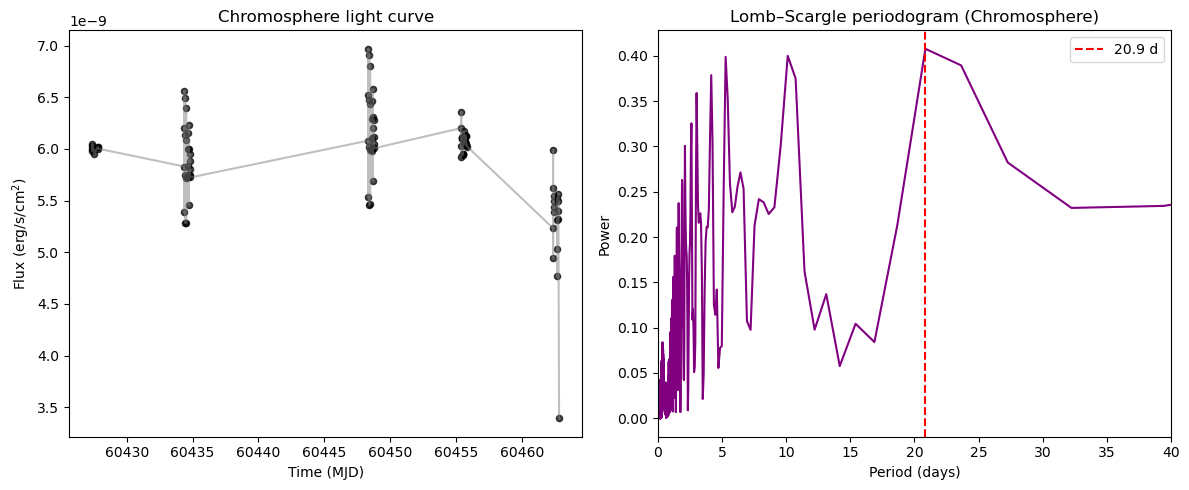

Best Chromosphere period: 20.86 days


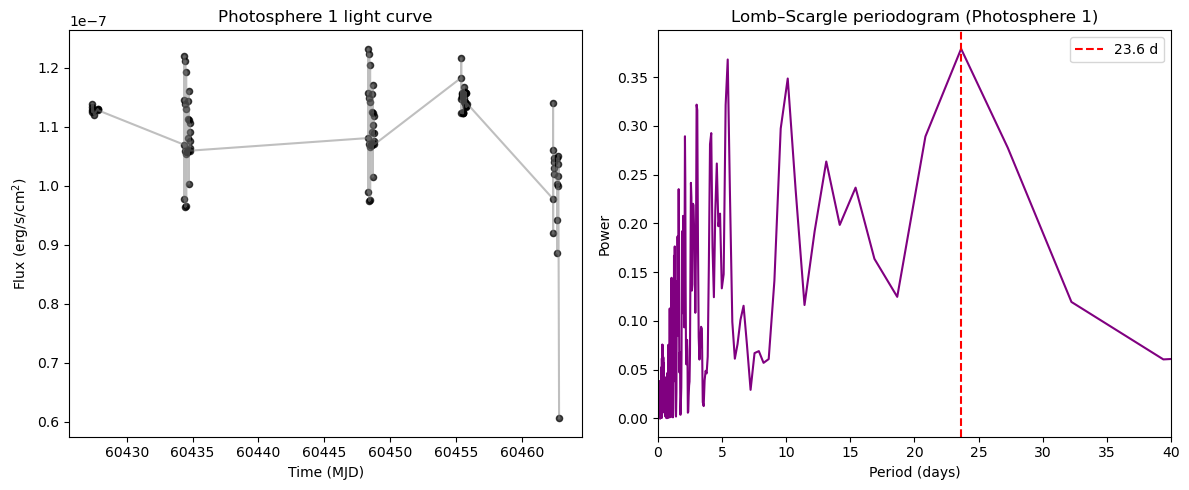

Best Photosphere 1 period: 23.64 days


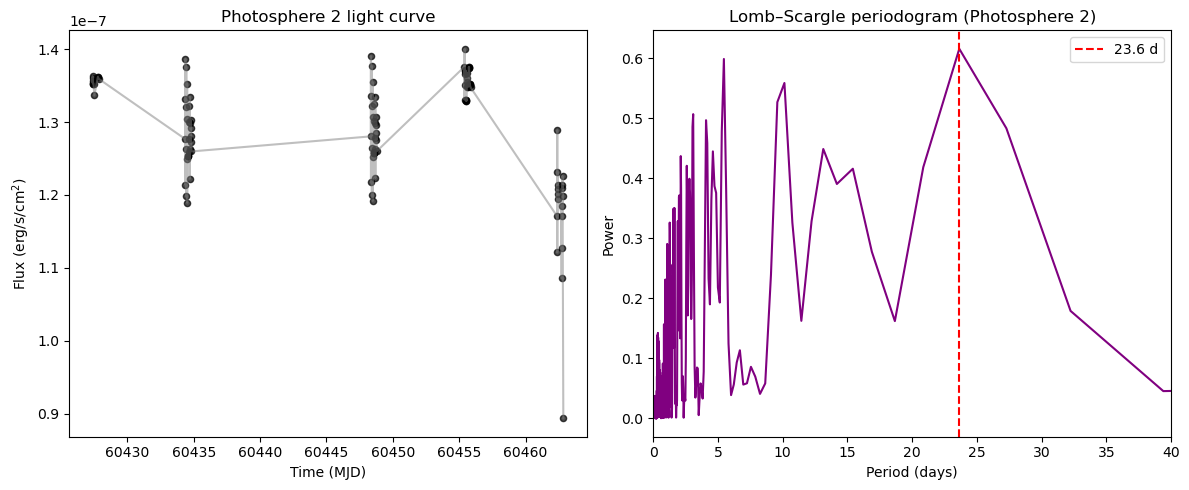

Best Photosphere 2 period: 23.64 days


In [306]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

# Example: time_mjd = np.array([...])
#          flux = np.array([...])   # replace with chrom_flux, phot1_flux, phot2_flux

def plot_lightcurve_and_ls(time_mjd, flux, label="Dataset"):
    # --- Light curve ---
    fig, axs = plt.subplots(1, 2, figsize=(12,5))

    axs[0].scatter(time_mjd, flux, s=20, c="k", alpha=0.7)
    axs[0].plot(time_mjd, flux, c="gray", alpha=0.5)
    axs[0].set_xlabel("Time (MJD)")
    axs[0].set_ylabel("Flux (erg/s/cm$^2$)")
    axs[0].set_title(f"{label} light curve")

    # --- LS periodogram ---
    ls = LombScargle(time_mjd, flux)
    freq, power = ls.autopower(method="fastchi2")

    best_period = 1.0 / freq[np.argmax(power)]
    axs[1].plot(1/freq, power, color="purple")
    axs[1].axvline(best_period, color="red", ls="--", label=f"{best_period:.1f} d")
    axs[1].set_xlim(0, 40)  # adjust as needed
    axs[1].set_xlabel("Period (days)")
    axs[1].set_ylabel("Power")
    axs[1].set_title(f"Lomb–Scargle periodogram ({label})")
    axs[1].legend()

    plt.tight_layout()
    plt.show()
    print(f"Best {label} period: {best_period:.2f} days")

# Example usage:
plot_lightcurve_and_ls(time_mjd, chrom_flux, label="Chromosphere")
plot_lightcurve_and_ls(time_mjd, phot1_flux, label="Photosphere 1")
plot_lightcurve_and_ls(time_mjd, phot2_flux, label="Photosphere 2")


Best period = 22.35 days


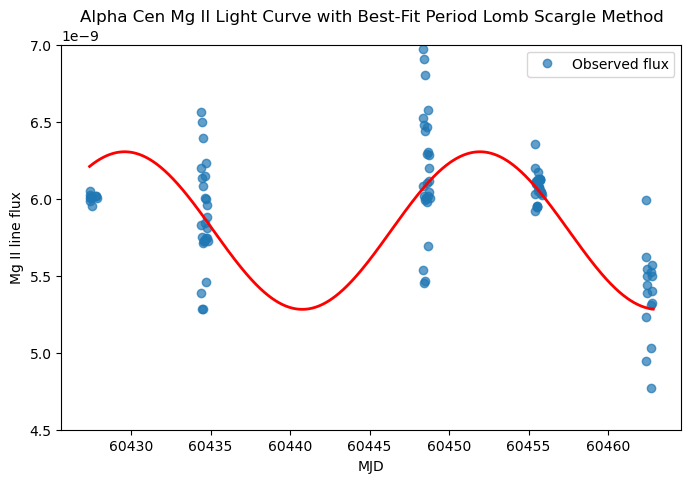

In [307]:
from astropy.timeseries import LombScargle

# Build Lomb–Scargle with your light curve
ls = LombScargle(time_mjd, chrom_flux)

# Find the frequency of the strongest signal
freq, power = ls.autopower(minimum_frequency=1/40,
                           maximum_frequency=1/5,
                           samples_per_peak=10)
best_freq = freq[np.argmax(power)]
best_period = 1 / best_freq
print(f"Best period = {best_period:.2f} days")

# Smooth time grid for plotting the model
time_fit = np.linspace(time_mjd.min(), time_mjd.max(), 1000)

# Model = sine wave at best frequency
flux_fit = ls.model(time_fit, best_freq)

# Plot observed points + sine wave fit
plt.figure(figsize=(8,5))
plt.plot(time_mjd, chrom_flux, "o", label="Observed flux", alpha=0.7)
plt.plot(time_fit, flux_fit, "r-", lw=2)
plt.xlabel("MJD")
plt.ylim(4.5*1e-9,7*1e-9)
plt.ylabel("Mg II line flux")
plt.title("Alpha Cen Mg II Light Curve with Best-Fit Period Lomb Scargle Method")
plt.legend()
plt.show()